# Yelp Business Dataset — Full EDA Framework
### Technical EDA → Business EDA → ML/BI Readiness EDA

This notebook performs a complete, **business-driven** exploratory data analysis of the Yelp
`business` table, structured to directly support the 5 planned BI modules:

| Module | Focus |
|---|---|
| M1 | Customer Experience Intelligence (ABSA / NLP) |
| M2 | Business Health & Performance Intelligence |
| M3 | Demand & Customer Traffic Forecasting |
| M4 | Review Trust & Fraud Detection |
| M5 | AI Review Summarization & Complaint Intelligence |

**Structure**

1. Dataset Overview
2. Data Quality Assessment
3. Business Profile
4. Category Analysis
5. Attribute Profiling & Data Dictionary
6. Rating & Review Analysis
7. Operational Analysis
8. Feature Relationships (Attribute vs Rating/Reviews)
9. Geographic Analysis
10. Correlation Analysis
11. BI Readiness / Silver-Layer Decision Report
12. Executive Summary of Findings

> Every chart or table below either (a) confirms a data-quality decision, or (b) directly feeds
> a Silver-layer transformation / Gold-layer BI module. Nothing here is EDA-for-EDA's-sake.


## 0. Setup & Data Load

In [0]:
%pip install seaborn --quiet


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql.functions import (
    col, count, countDistinct, avg, round as spround, desc, asc,
    explode, split, trim, when, isnan, isnull, length, size
)
from pyspark.sql.types import StructType, NumericType

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


In [0]:
# Load raw business dataset
business_df = spark.read.json(
    "/Volumes/vita/yelp/data/yelp_academic_dataset_business.json"
)
print(f"Raw rows: {business_df.count():,}  |  Raw columns: {len(business_df.columns)}")
display(business_df.limit(5))


Raw rows: 150,346  |  Raw columns: 14


address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state
"1616 Chapala St, Ste 2","List(null, null, null, null, null, null, null, null, null, null, null, True, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null)",Pns2l4eNsfO8kk83dixA6A,"Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists",Santa Barbara,null,0,34.4266787,-119.7111968,"Abby Rappoport, LAC, CMQ",93101,7,5.0,CA
87 Grasso Plaza Shopping Center,"List(null, null, null, null, null, null, null, null, null, True, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null)",mpf3x-BjTdTEA3yCZrAYPw,"Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services",Affton,"List(8:0-18:30, 0:0-0:0, 8:0-14:0, null, 8:0-18:30, 8:0-18:30, 8:0-18:30)",1,38.551126,-90.335695,The UPS Store,63123,15,3.0,MO
5255 E Broadway Blvd,"List(null, null, null, null, null, null, null, True, null, True, {'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}, False, False, False, null, null, False, null, null, null, null, null, False, False, null, null, null, False, null, null, False, null, 2, False, null, False, null, True, u'no')",tUFrWirKiKi_TAnsVWINQQ,"Department Stores, Shopping, Fashion, Home & Garden, Electronics, Furniture Stores",Tucson,"List(8:0-23:0, 8:0-22:0, 8:0-23:0, 8:0-22:0, 8:0-22:0, 8:0-22:0, 8:0-22:0)",0,32.223236,-110.880452,Target,85711,22,3.5,AZ
935 Race St,"List(null, null, u'none', null, null, null, null, True, null, False, {'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}, False, True, null, null, null, null, null, null, null, null, null, null, null, null, null, null, False, null, null, False, null, 1, null, null, True, null, null, u'free')",MTSW4McQd7CbVtyjqoe9mw,"Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries",Philadelphia,"List(7:0-21:0, 7:0-20:0, 7:0-21:0, 7:0-21:0, 7:0-20:0, 7:0-20:0, 7:0-20:0)",1,39.9555052,-75.1555641,St Honore Pastries,19107,80,4.0,PA
101 Walnut St,"List(null, null, null, null, null, null, null, True, null, True, {'garage': None, 'street': None, 'validated': None, 'lot': True, 'valet': False}, null, False, null, null, null, null, null, null, True, null, null, null, null, null, null, null, null, null, null, null, null, null, null, null, True, null, True, null)",mWMc6_wTdE0EUBKIGXDVfA,"Brewpubs, Breweries, Food",Green Lane,"List(12:0-22:0, null, 12:0-22:0, 12:0-18:0, 16:0-22:0, null, 14:0-22:0)",1,40.3381827,-75.4716585,Perkiomen Valley Brewery,18054,13,4.5,PA


### Flatten nested attributes

All `StructType` columns (`attributes`, `hours`) are recursively flattened so every leaf field becomes its own top-level column (e.g. `attributes_WiFi`, `attributes_BusinessParking_garage`, `hours_Monday`).

In [0]:
def flatten_df(df):
    """
    Recursively flattens all StructType columns.
    Arrays are left as-is.
    """
    while True:
        struct_cols = [
            field.name
            for field in df.schema.fields
            if isinstance(field.dataType, StructType)
        ]
        if not struct_cols:
            break
        for sc in struct_cols:
            expanded = [
                col(f"{sc}.{sub.name}").alias(f"{sc}_{sub.name}")
                for sub in df.schema[sc].dataType.fields
            ]
            df = df.select(
                [c for c in df.columns if c != sc] + expanded
            )
    return df

business_flat = flatten_df(business_df)
print(f"Flattened rows: {business_flat.count():,}  |  Flattened columns: {len(business_flat.columns)}")


Flattened rows: 150,346  |  Flattened columns: 58


In [0]:
# Helper: fuzzy-find a flattened column by keyword (robust to schema drift across
# Yelp dataset versions). Returns None if nothing matches.
def find_col(keyword, columns=None):
    columns = columns or business_flat.columns
    matches = [c for c in columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

def find_cols(keyword, columns=None):
    columns = columns or business_flat.columns
    return [c for c in columns if keyword.lower() in c.lower()]

attribute_columns = sorted([c for c in business_flat.columns if c.startswith("attributes_")])
hours_columns      = sorted([c for c in business_flat.columns if c.startswith("hours_")])
core_columns       = [c for c in business_flat.columns if not c.startswith("attributes_") and not c.startswith("hours_")]

print(f"Core columns      : {len(core_columns)}  -> {core_columns}")
print(f"Attribute columns : {len(attribute_columns)}")
print(f"Hours columns     : {len(hours_columns)}")


Core columns      : 12  -> ['address', 'business_id', 'categories', 'city', 'is_open', 'latitude', 'longitude', 'name', 'postal_code', 'review_count', 'stars', 'state']
Attribute columns : 39
Hours columns     : 7


## 1. Dataset Overview
Goal: understand shape, schema and grain before anything else.

In [0]:
total_rows = business_flat.count()
total_cols = len(business_flat.columns)
print(f"Rows    : {total_rows:,}")
print(f"Columns : {total_cols:,}")


Rows    : 150,346
Columns : 58


In [0]:
business_flat.printSchema()


root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- attributes_AcceptsInsurance: string (nullable = true)
 |-- attributes_AgesAllowed: string (nullable = true)
 |-- attributes_Alcohol: string (nullable = true)
 |-- attributes_Ambience: string (nullable = true)
 |-- attributes_BYOB: string (nullable = true)
 |-- attributes_BYOBCorkage: string (nullable = true)
 |-- attributes_BestNights: string (nullable = true)
 |-- attributes_BikeParking: string (nullable = true)
 |-- attributes_BusinessAcceptsBitcoin: string (nullable = true)
 |-- attributes_BusinessAcceptsCred

In [0]:
display(business_flat.limit(10))


address,business_id,categories,city,is_open,latitude,longitude,name,postal_code,review_count,stars,state,attributes_AcceptsInsurance,attributes_AgesAllowed,attributes_Alcohol,attributes_Ambience,attributes_BYOB,attributes_BYOBCorkage,attributes_BestNights,attributes_BikeParking,attributes_BusinessAcceptsBitcoin,attributes_BusinessAcceptsCreditCards,attributes_BusinessParking,attributes_ByAppointmentOnly,attributes_Caters,attributes_CoatCheck,attributes_Corkage,attributes_DietaryRestrictions,attributes_DogsAllowed,attributes_DriveThru,attributes_GoodForDancing,attributes_GoodForKids,attributes_GoodForMeal,attributes_HairSpecializesIn,attributes_HappyHour,attributes_HasTV,attributes_Music,attributes_NoiseLevel,attributes_Open24Hours,attributes_OutdoorSeating,attributes_RestaurantsAttire,attributes_RestaurantsCounterService,attributes_RestaurantsDelivery,attributes_RestaurantsGoodForGroups,attributes_RestaurantsPriceRange2,attributes_RestaurantsReservations,attributes_RestaurantsTableService,attributes_RestaurantsTakeOut,attributes_Smoking,attributes_WheelchairAccessible,attributes_WiFi,hours_Friday,hours_Monday,hours_Saturday,hours_Sunday,hours_Thursday,hours_Tuesday,hours_Wednesday
"1616 Chapala St, Ste 2",Pns2l4eNsfO8kk83dixA6A,"Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists",Santa Barbara,0,34.4266787,-119.7111968,"Abby Rappoport, LAC, CMQ",93101,7,5.0,CA,null,null,null,null,null,null,null,null,null,null,null,True,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
87 Grasso Plaza Shopping Center,mpf3x-BjTdTEA3yCZrAYPw,"Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services",Affton,1,38.551126,-90.335695,The UPS Store,63123,15,3.0,MO,null,null,null,null,null,null,null,null,null,True,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,8:0-18:30,0:0-0:0,8:0-14:0,null,8:0-18:30,8:0-18:30,8:0-18:30
5255 E Broadway Blvd,tUFrWirKiKi_TAnsVWINQQ,"Department Stores, Shopping, Fashion, Home & Garden, Electronics, Furniture Stores",Tucson,0,32.223236,-110.880452,Target,85711,22,3.5,AZ,null,null,null,null,null,null,null,True,null,True,"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}",False,False,False,null,null,False,null,null,null,null,null,False,False,null,null,null,False,null,null,False,null,2,False,null,False,null,True,u'no',8:0-23:0,8:0-22:0,8:0-23:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0
935 Race St,MTSW4McQd7CbVtyjqoe9mw,"Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries",Philadelphia,1,39.9555052,-75.1555641,St Honore Pastries,19107,80,4.0,PA,null,null,u'none',null,null,null,null,True,null,False,"{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}",False,True,null,null,null,null,null,null,null,null,null,null,null,null,null,null,False,null,null,False,null,1,null,null,True,null,null,u'free',7:0-21:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-20:0,7:0-20:0,7:0-20:0
101 Walnut St,mWMc6_wTdE0EUBKIGXDVfA,"Brewpubs, Breweries, Food",Green Lane,1,40.3381827,-75.4716585,Perkiomen Valley Brewery,18054,13,4.5,PA,null,null,null,null,null,null,null,True,null,True,"{'garage': None, 'street': None, 'validated': None, 'lot': True, 'valet': False}",null,False,null,null,null,null,null,null,True,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,True,null,True,null,12:0-22:0,null,12:0-22:0,12:0-18:0,16:0-22:0,null,14:0-22:0
615 S Main St,CF33F8-E6oudUQ46HnavjQ,"Burgers, Fast Food, Sandwiches, Food, Ice Cream & Frozen Yogurt, Restaurants",Ashland City,1,36.269593,-87.058943,Sonic Drive-In,37015,6,2.0,TN,null,null,u'none',None,null,null,null,False,null,True,None,False,False,False,null,null,False,True,null,True,null,null,False,True,null,null,null,True,u'casual',null,True,True,1,Fals

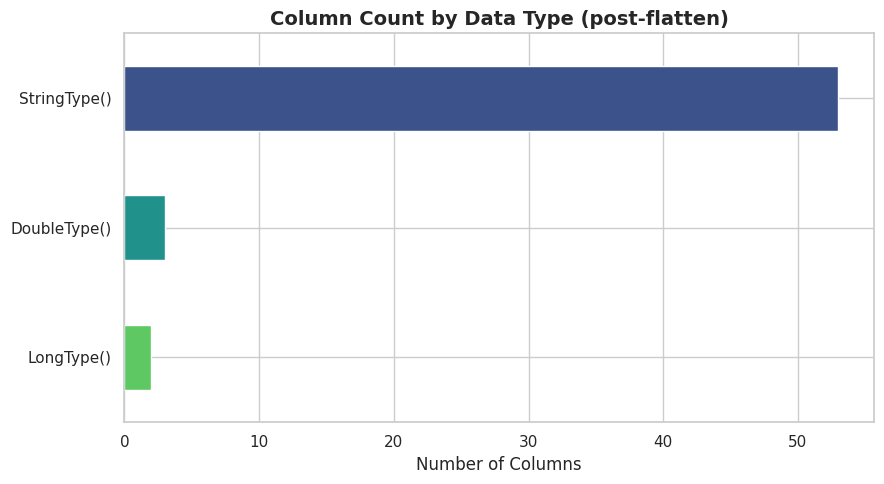

StringType()    53
DoubleType()     3
LongType()       2
Name: count, dtype: int64


In [0]:
# Column type breakdown — informs which columns are candidates for numeric EDA vs categorical EDA
dtype_counts = pd.Series([str(f.dataType) for f in business_flat.schema.fields]).value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
dtype_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(dtype_counts)))
ax.set_title("Column Count by Data Type (post-flatten)")
ax.set_xlabel("Number of Columns")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(dtype_counts)


## 2. Data Quality Assessment
Order of checks: duplicate keys → exact duplicate rows → missingness → constant columns → cardinality.

### 2.1 Duplicate `business_id` (primary key check)

In [0]:
dup_ids = (
    business_flat
    .groupBy("business_id")
    .count()
    .filter("count > 1")
)
dup_id_count = dup_ids.count()
print(f"Duplicate business_id groups: {dup_id_count}")
display(dup_ids)


Duplicate business_id groups: 0


business_id,count


### 2.2 Exact duplicate rows (all columns identical)

Total Rows     : 150,346
Distinct Rows  : 150,346
Duplicate Rows : 0


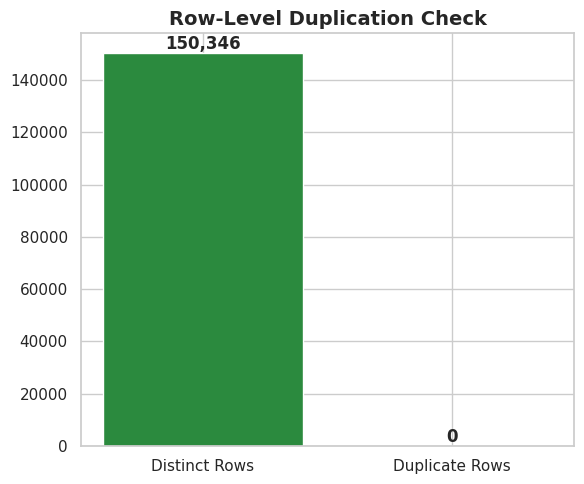

In [0]:
distinct_rows = business_flat.distinct().count()
print(f"Total Rows     : {total_rows:,}")
print(f"Distinct Rows  : {distinct_rows:,}")
print(f"Duplicate Rows : {total_rows - distinct_rows:,}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Distinct Rows", "Duplicate Rows"],
       [distinct_rows, total_rows - distinct_rows],
       color=["#2b8a3e", "#c92a2a"])
ax.set_title("Row-Level Duplication Check")
for i, v in enumerate([distinct_rows, total_rows - distinct_rows]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()


### 2.3 Missing value profile — ALL columns

In [0]:
missing_summary = []
for c in business_flat.columns:
    non_null = business_flat.filter(col(c).isNotNull()).count()
    null_ct = total_rows - non_null
    missing_summary.append((c, non_null, null_ct, round(null_ct * 100 / total_rows, 2)))

missing_df = pd.DataFrame(missing_summary, columns=["Column", "Non_Null", "Null_Count", "Missing_%"])
missing_df = missing_df.sort_values("Missing_%", ascending=False).reset_index(drop=True)
display(spark.createDataFrame(missing_df))


Column,Non_Null,Null_Count,Missing_%
attributes_RestaurantsCounterService,19,150327,99.99
attributes_DietaryRestrictions,31,150315,99.98
attributes_Open24Hours,39,150307,99.97
attributes_AgesAllowed,129,150217,99.91
attributes_HairSpecializesIn,1065,149281,99.29
attributes_BYOBCorkage,1444,148902,99.04
attributes_Corkage,3553,146793,97.64
attributes_BYOB,4451,145895,97.04
attributes_Smoking,4567,145779,96.96
attributes_GoodForDancing,4628,145718,96.92


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804595-3911586866:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y="Column", x="Missing_%", ax=ax, palette="rocket")


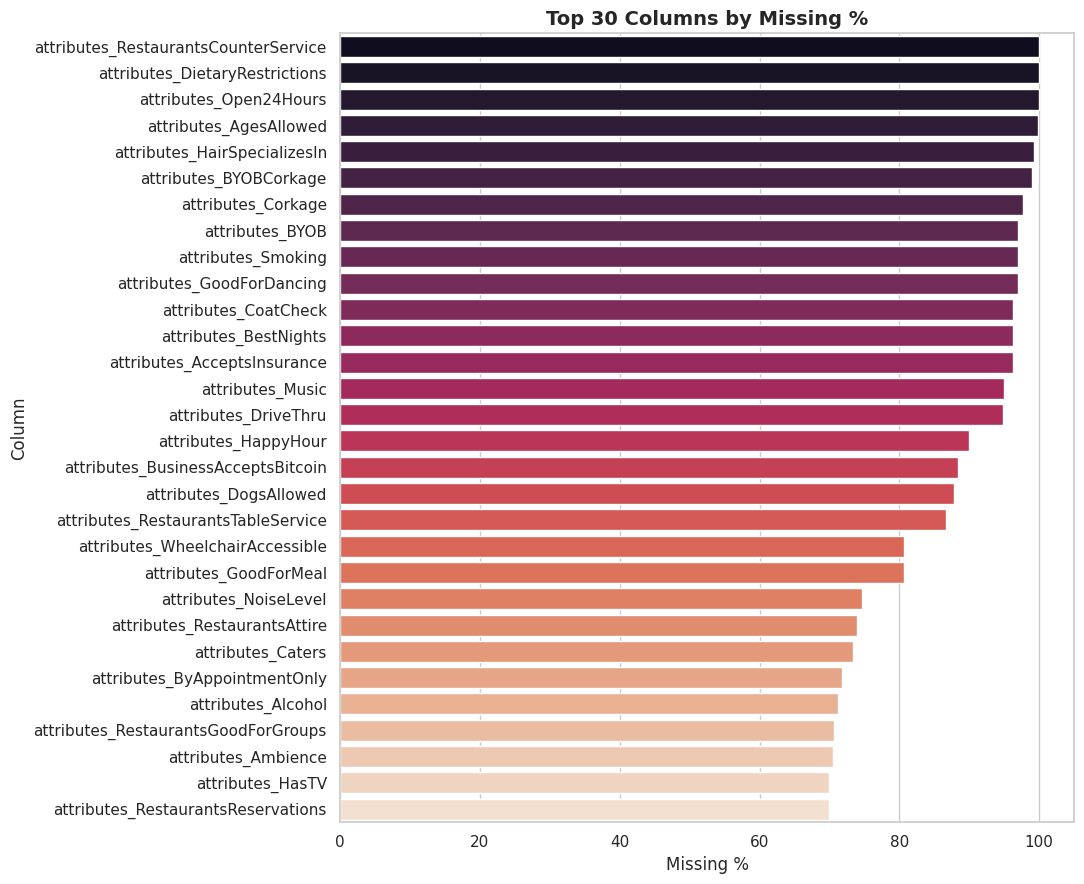

In [0]:
# Visualize the 30 columns with highest missingness
top_missing = missing_df.head(30)

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(data=top_missing, y="Column", x="Missing_%", ax=ax, palette="rocket")
ax.set_title("Top 30 Columns by Missing %")
ax.set_xlabel("Missing %")
plt.tight_layout()
plt.show()


### 2.4 Constant-value columns (zero information — drop candidates)

In [0]:
constant_cols = []
for c in business_flat.columns:
    d = business_flat.select(c).distinct().count()
    if d <= 1:
        constant_cols.append(c)

print(f"Constant columns ({len(constant_cols)}): {constant_cols}")


Constant columns (0): []


### 2.5 Cardinality profile (distinct value counts per column)

In [0]:
cardinality = []
for c in business_flat.columns:
    d = business_flat.select(c).distinct().count()
    cardinality.append((c, d))

card_df = pd.DataFrame(cardinality, columns=["Column", "Distinct_Values"]).sort_values("Distinct_Values", ascending=False)
display(spark.createDataFrame(card_df))


Column,Distinct_Values
business_id,150346
latitude,135593
longitude,131918
address,122844
name,114117
categories,83161
postal_code,3362
attributes_Ambience,2415
hours_Friday,1539
hours_Thursday,1463


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804600-3318589640:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_card, y="Column", x="Distinct_Values", ax=ax, palette="mako")


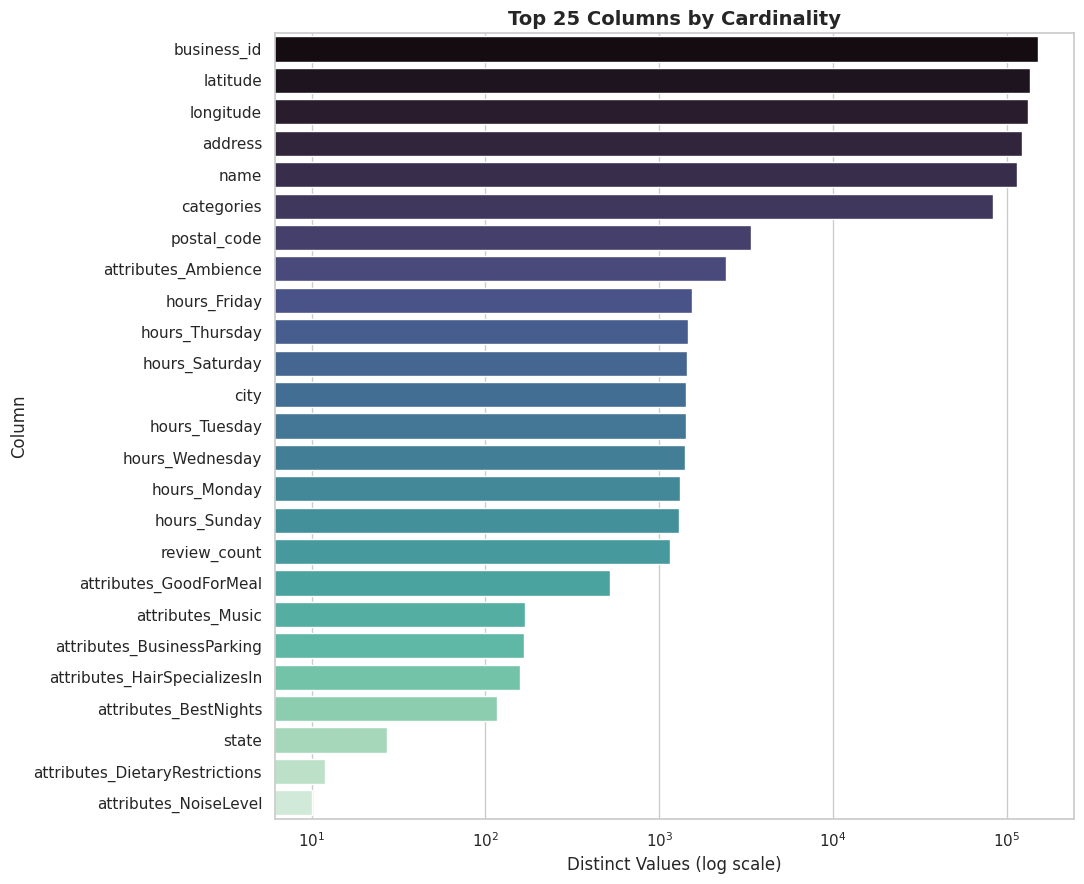

In [0]:
# High-cardinality columns are usually IDs / free text / geo — not useful as categorical BI features
fig, ax = plt.subplots(figsize=(11, 9))
top_card = card_df.head(25)
sns.barplot(data=top_card, y="Column", x="Distinct_Values", ax=ax, palette="mako")
ax.set_title("Top 25 Columns by Cardinality")
ax.set_xscale("log")
ax.set_xlabel("Distinct Values (log scale)")
plt.tight_layout()
plt.show()


## 3. Business Profile
Where are businesses located, and are they active?

### 3.1 Businesses by State

state,count
PA,34039
FL,26330
TN,12056
IN,11247
MO,10913
LA,9924
AZ,9912
NJ,8536
NV,7715
AB,5573


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804603-4157002612:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x="state", y="count", ax=ax, palette="viridis")


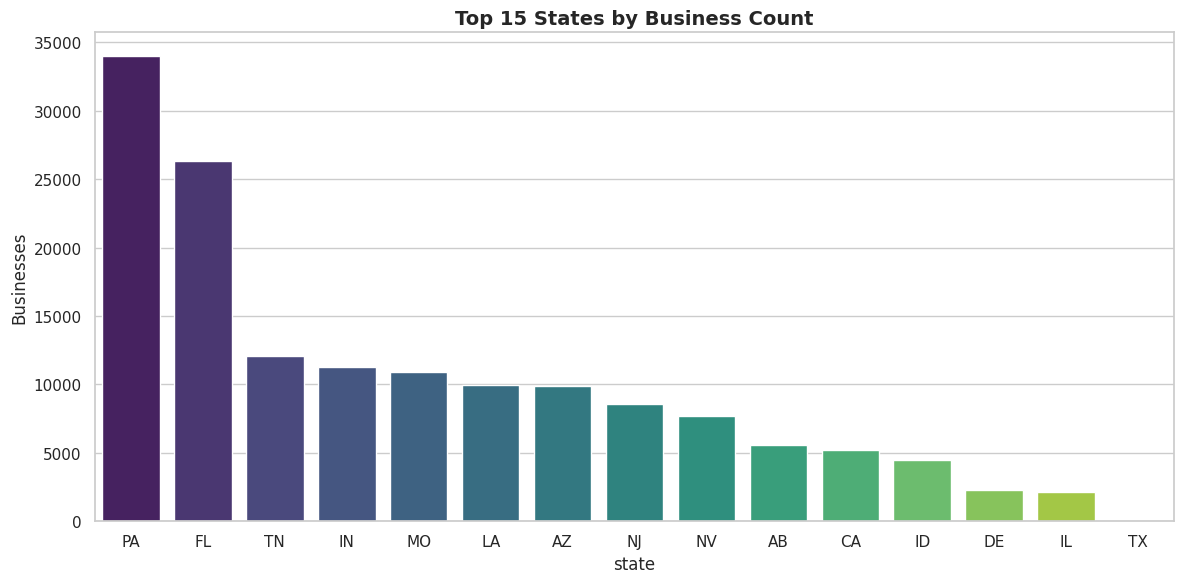

In [0]:
state_pd = (
    business_flat.groupBy("state").count().orderBy(desc("count"))
).toPandas()

display(spark.createDataFrame(state_pd))

fig, ax = plt.subplots(figsize=(12, 6))
top_states = state_pd.head(15)
sns.barplot(data=top_states, x="state", y="count", ax=ax, palette="viridis")
ax.set_title("Top 15 States by Business Count")
ax.set_ylabel("Businesses")
plt.tight_layout()
plt.show()


### 3.2 Businesses by City (Top 20)

city,count
Philadelphia,14569
Tucson,9250
Tampa,9050
Indianapolis,7540
Nashville,6971
New Orleans,6209
Reno,5935
Edmonton,5054
Saint Louis,4827
Santa Barbara,3829


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804605-3642257148:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_pd, y="city", x="count", ax=ax, palette="crest")


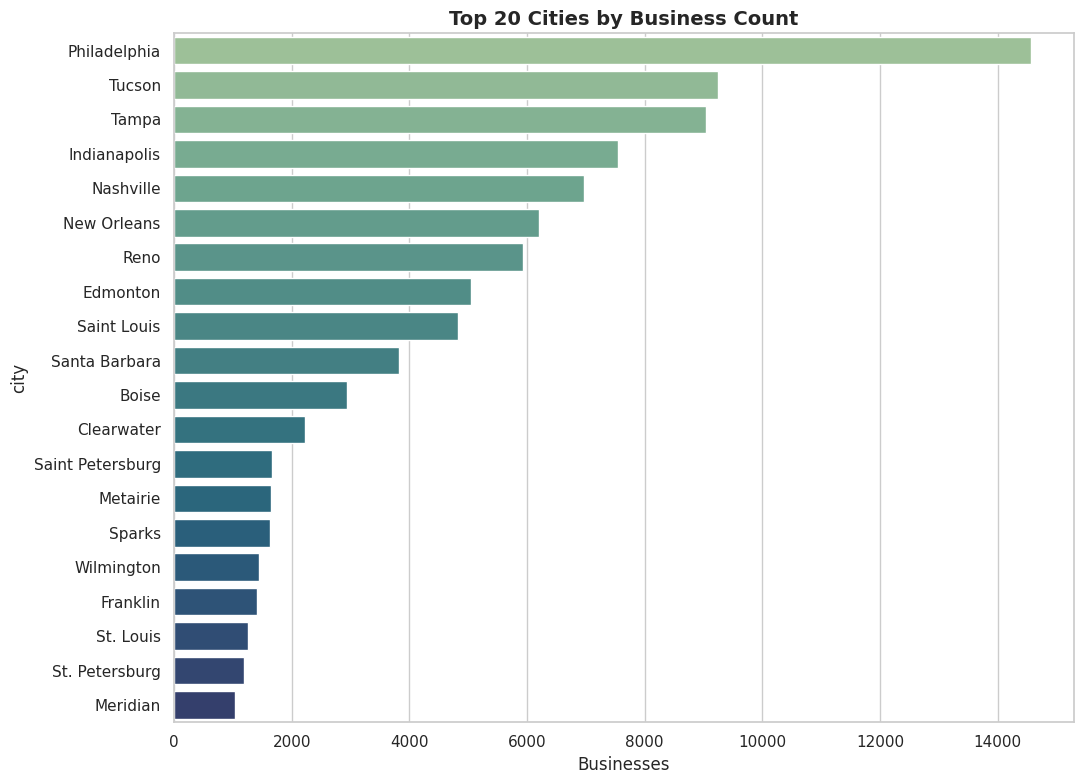

In [0]:
city_pd = (
    business_flat.groupBy("city").count().orderBy(desc("count")).limit(20)
).toPandas()

display(spark.createDataFrame(city_pd))

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=city_pd, y="city", x="count", ax=ax, palette="crest")
ax.set_title("Top 20 Cities by Business Count")
ax.set_xlabel("Businesses")
plt.tight_layout()
plt.show()


### 3.3 Open vs Closed Businesses
Directly relevant to **M2 (Business Health)** and **M3 (Demand Forecasting)** — closed businesses should typically be excluded from forecasting/training data.

is_open,count
1,119698
0,30648


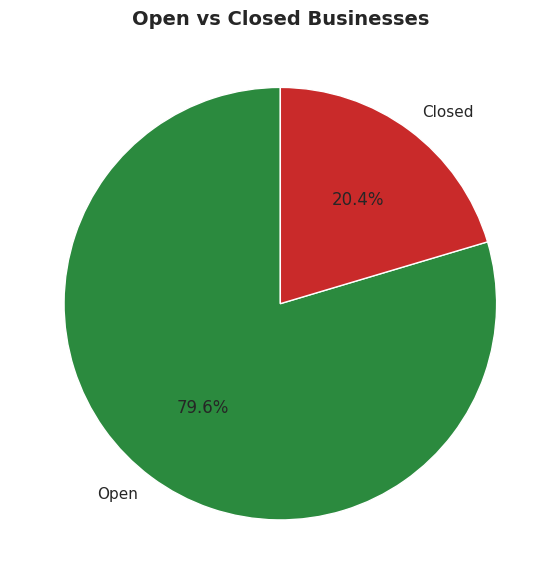

Closed business share: 20.38% — decide whether M3 training data should filter is_open == 1.


In [0]:
open_pd = business_flat.groupBy("is_open").count().toPandas()
display(spark.createDataFrame(open_pd))

labels = open_pd["is_open"].map({1: "Open", 0: "Closed"}).fillna(open_pd["is_open"].astype(str))
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(open_pd["count"], labels=labels, autopct="%1.1f%%",
       colors=["#2b8a3e", "#c92a2a"], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Open vs Closed Businesses")
plt.tight_layout()
plt.show()

closed_pct = round(open_pd.loc[open_pd["is_open"] == 0, "count"].sum() * 100 / open_pd["count"].sum(), 2)
print(f"Closed business share: {closed_pct}% — decide whether M3 training data should filter is_open == 1.")


## 4. Category Analysis
Categories are multi-valued (comma-separated) — must be exploded before aggregation. Central to **M1** (which review aspects matter per category) and **M5** (topic priors).

In [0]:
category_df = (
    business_flat
    .withColumn("category", explode(split(col("categories"), ",")))
    .withColumn("category", trim(col("category")))
)

n_missing_categories = business_flat.filter(col("categories").isNull()).count()
print(f"Businesses with NULL categories: {n_missing_categories:,} ({round(n_missing_categories*100/total_rows,2)}%)")


Businesses with NULL categories: 103 (0.07%)


### 4.1 Top Categories (overall)

category,count
Restaurants,52268
Food,27781
Shopping,24395
Home Services,14356
Beauty & Spas,14292
Nightlife,12281
Health & Medical,11890
Local Services,11198
Bars,11065
Automotive,10773


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804611-888764093:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories_pd, y="category", x="count", ax=ax, palette="flare")


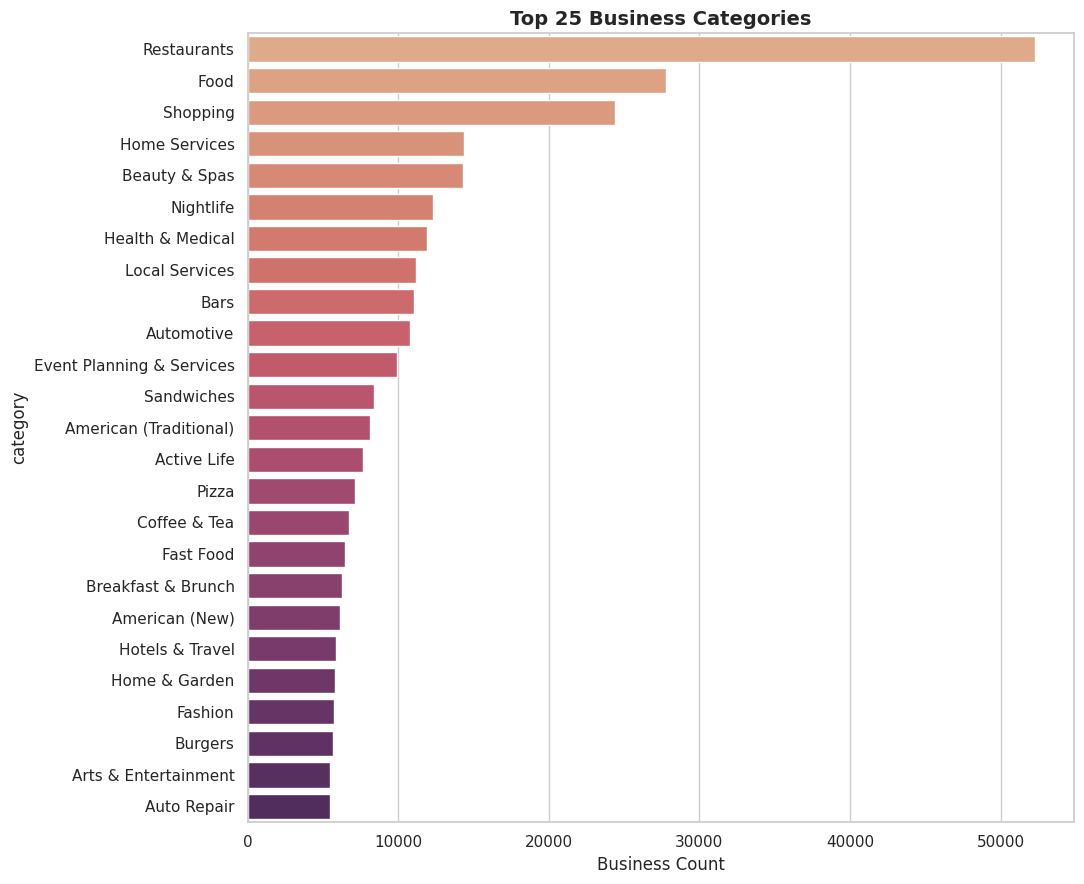

In [0]:
top_categories_pd = (
    category_df.groupBy("category").count().orderBy(desc("count")).limit(25)
).toPandas()

display(spark.createDataFrame(top_categories_pd))

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(data=top_categories_pd, y="category", x="count", ax=ax, palette="flare")
ax.set_title("Top 25 Business Categories")
ax.set_xlabel("Business Count")
plt.tight_layout()
plt.show()


### 4.2 Top Categories excluding 'Restaurants' (avoids one umbrella tag dominating the chart)

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804613-3247256065:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories_ex_pd, y="category", x="count", ax=ax, palette="flare")


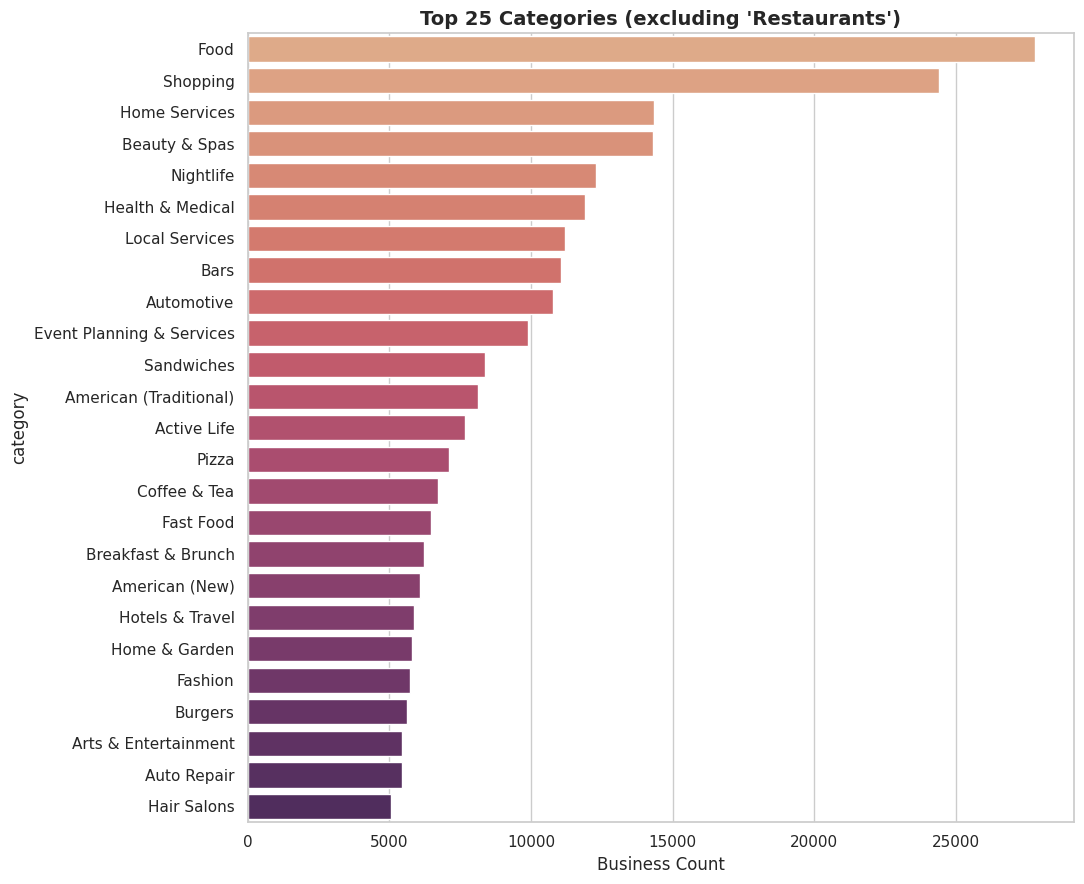

In [0]:
top_categories_ex_pd = (
    category_df.filter(col("category") != "Restaurants")
    .groupBy("category").count().orderBy(desc("count")).limit(25)
).toPandas()

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(data=top_categories_ex_pd, y="category", x="count", ax=ax, palette="flare")
ax.set_title("Top 25 Categories (excluding 'Restaurants')")
ax.set_xlabel("Business Count")
plt.tight_layout()
plt.show()


### 4.3 How many categories does a typical business have?

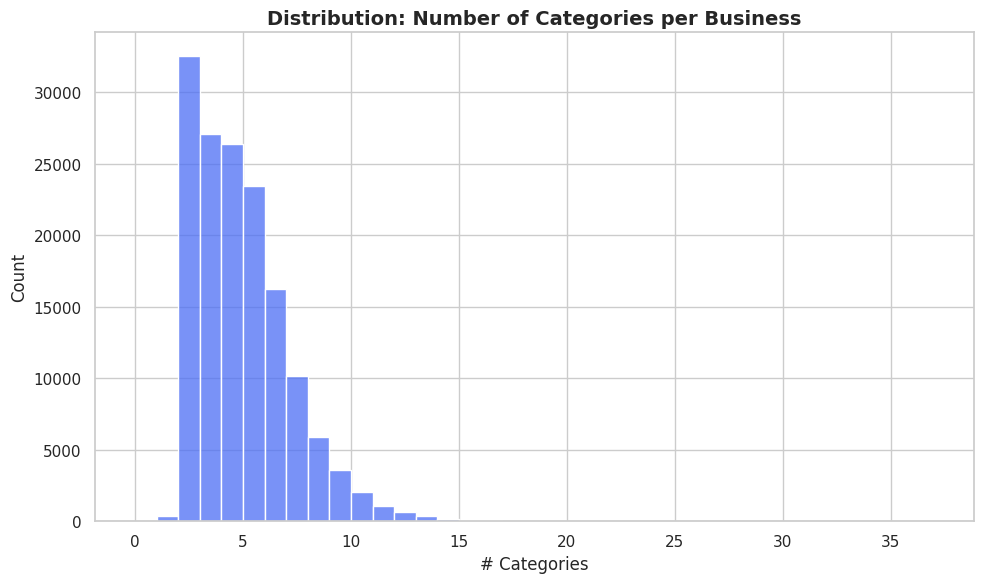

count    150243.000000
mean          4.450071
std           2.231462
min           1.000000
25%           3.000000
50%           4.000000
75%           6.000000
max          36.000000
Name: n_categories, dtype: float64


In [0]:
cat_count_per_biz = (
    category_df.groupBy("business_id").count().withColumnRenamed("count", "n_categories")
).toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(cat_count_per_biz["n_categories"], bins=range(0, cat_count_per_biz["n_categories"].max()+2),
             ax=ax, color="#4c6ef5")
ax.set_title("Distribution: Number of Categories per Business")
ax.set_xlabel("# Categories")
plt.tight_layout()
plt.show()

print(cat_count_per_biz["n_categories"].describe())


## 5. Attribute Profiling & Data Dictionary
For every `attributes_*` column: coverage, missingness, distinct values, top values, and which
categories actually use it. This table is the single source of truth for every Silver-layer
keep/drop/flatten decision.

In [0]:
summary = []

# Extract all attributes_* columns
attribute_columns = [c for c in business_flat.columns if c.startswith("attributes_")]

for attribute in attribute_columns:
    non_null = business_flat.filter(col(attribute).isNotNull()).count()
    null_count = total_rows - non_null
    coverage = round(non_null * 100 / total_rows, 2)
    missing = round(null_count * 100 / total_rows, 2)

    distinct_values = (
        business_flat.filter(col(attribute).isNotNull())
        .select(attribute).distinct().count()
    )

    values = (
        business_flat.filter(col(attribute).isNotNull())
        .groupBy(attribute).count()
        .orderBy(desc("count")).limit(5).collect()
    )
    top_values = ", ".join([str(v[attribute]) for v in values])

    categories = (
        business_flat.filter(col(attribute).isNotNull())
        .withColumn("category", explode(split(col("categories"), ",")))
        .withColumn("category", trim(col("category")))
        .groupBy("category").count()
        .orderBy(desc("count")).limit(10).collect()
    )
    top_categories = ", ".join([f"{c['category']} ({c['count']})" for c in categories])

    summary.append((attribute, non_null, null_count, coverage, missing,
                     distinct_values, top_values, top_categories))

attr_profile_pd = pd.DataFrame(summary, columns=[
    "Attribute", "Businesses_Using", "Null_Count", "Coverage_%", "Missing_%",
    "Distinct_Values", "Top_5_Values", "Top_10_Categories_Using_Attribute"
]).sort_values("Coverage_%", ascending=False).reset_index(drop=True)

display(spark.createDataFrame(attr_profile_pd))


Attribute,Businesses_Using,Null_Count,Coverage_%,Missing_%,Distinct_Values,Top_5_Values,Top_10_Categories_Using_Attribute
attributes_BusinessAcceptsCreditCards,119765,30581,79.66,20.34,3,"True, False, None","Restaurants (45557), Food (24351), Shopping (21683), Beauty & Spas (12819), Home Services (12207), Nightlife (10993), Bars (9952), Local Services (9820), Health & Medical (8952), Event Planning & Services (8944)"
attributes_BusinessParking,91085,59261,60.58,39.42,165,"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}, {'garage': False, 'street': False, 'validated': False, 'lot': False, 'valet': False}, {'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}, {'garage': False, 'street': True, 'validated': False, 'lot': True, 'valet': False}, None","Restaurants (45611), Food (24707), Shopping (19701), Beauty & Spas (12314), Nightlife (11174), Bars (10176), American (Traditional) (7500), Sandwiches (7240), Coffee & Tea (6027), Pizza (5862)"
attributes_RestaurantsPriceRange2,85314,65032,56.75,43.25,5,"2, 1, 3, 4, None","Restaurants (44500), Food (23341), Shopping (18700), Beauty & Spas (11283), Nightlife (10586), Bars (9634), Sandwiches (7294), American (Traditional) (7287), Event Planning & Services (6292), Pizza (6035)"
attributes_BikeParking,72638,77708,48.31,51.69,3,"True, False, None","Restaurants (35483), Food (20138), Shopping (16270), Beauty & Spas (10074), Nightlife (9433), Bars (8655), American (Traditional) (6444), Sandwiches (5957), Active Life (5060), Coffee & Tea (4919)"
attributes_RestaurantsTakeOut,59857,90489,39.81,60.19,3,"True, False, None","Restaurants (48713), Food (23483), Nightlife (8561), Bars (8178), Sandwiches (8056), American (Traditional) (7794), Pizza (6723), Fast Food (6283), Breakfast & Brunch (5965), Coffee & Tea (5912)"
attributes_WiFi,56914,93432,37.86,62.14,7,"u'free', u'no', 'free', 'no', u'paid'","Restaurants (37748), Food (15774), Nightlife (8695), Bars (8218), American (Traditional) (6703), Sandwiches (6141), Event Planning & Services (6038), Coffee & Tea (5805), Breakfast & Brunch (5176), American (New) (5110)"
attributes_RestaurantsDelivery,56282,94064,37.43,62.57,3,"True, False, None","Restaurants (47654), Food (19922), Nightlife (8333), Bars (7978), Sandwiches (7902), American (Traditional) (7712), Pizza (6649), Fast Food (6315), Breakfast & Brunch (5868), American (New) (5743)"
attributes_GoodForKids,53375,96971,35.5,64.5,3,"True, False, None","Restaurants (40977), Food (11782), Nightlife (8082), Bars (7341), American (Traditional) (7103), Sandwiches (6596), Pizza (5807), Active Life (5798), Fast Food (5384), American (New) (5384)"
attributes_OutdoorSeating,48802,101544,32.46,67.54,3,"False, True, None","Restaurants (43639), Food (14661), Nightlife (10973), Bars (10055), American (Traditional) (7480), Sandwiches (6907), Pizza (5909), American (New) (5755), Breakfast & Brunch (5555), Coffee & Tea (5405)"
attributes_RestaurantsReservations,45247,105099,30.1,69.9,3,"False, True, None","Restaurants (43106), Food (11910), Nightlife (9501), Bars (9185), American (Traditional) (7383), Sandwiches (7053), Pizza (6066), Fast Food (5643), American (New) (5635), Breakfast & Brunch (5408)"


/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804618-3579582576:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=attr_profile_pd, y="Attribute", x="Coverage_%", ax=ax, palette="viridis")


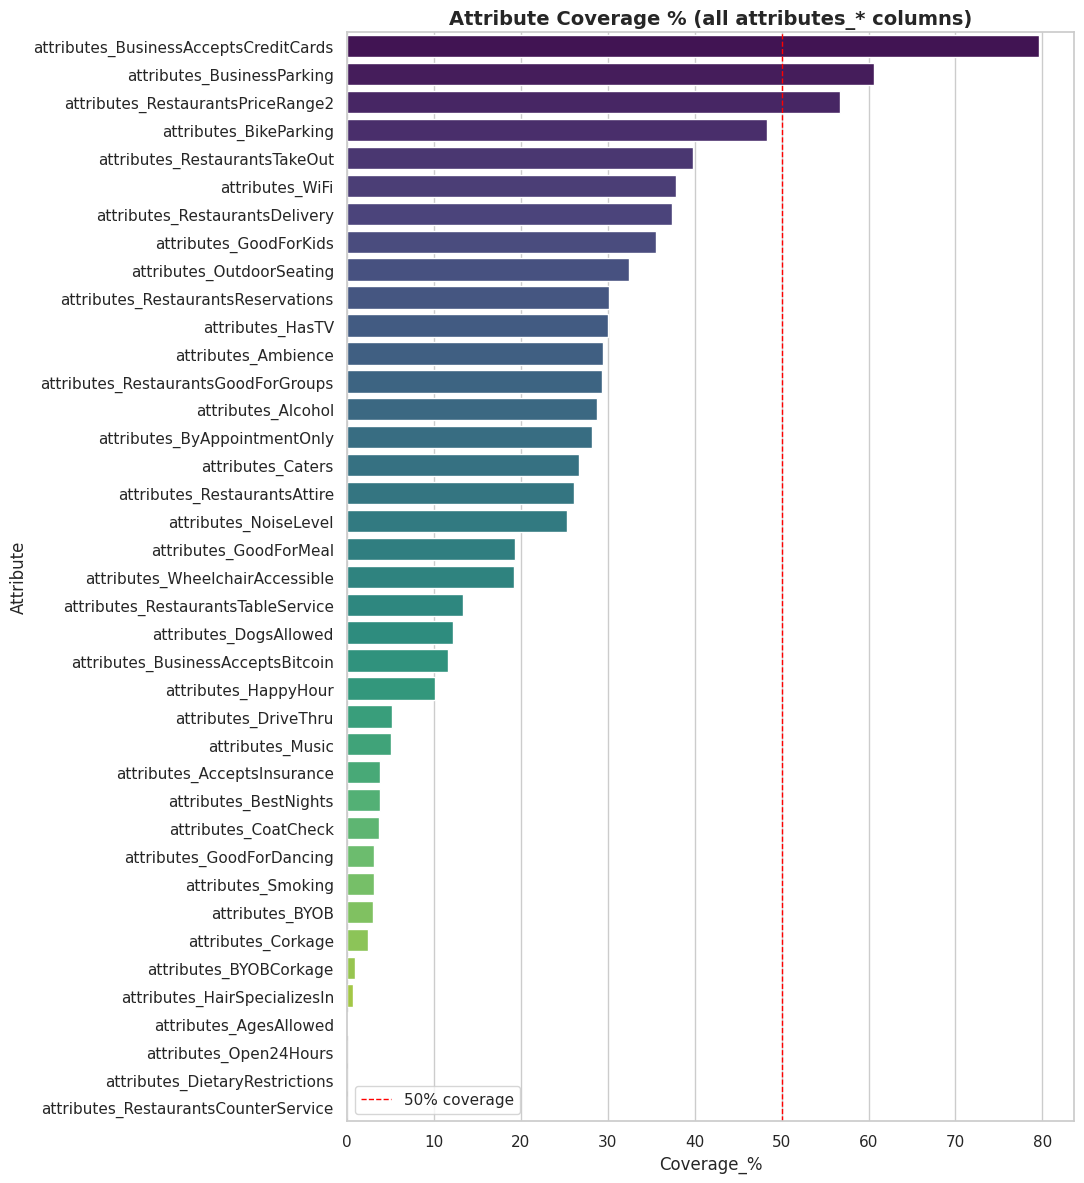

In [0]:
fig, ax = plt.subplots(figsize=(11, 12))
sns.barplot(data=attr_profile_pd, y="Attribute", x="Coverage_%", ax=ax, palette="viridis")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% coverage")
ax.set_title("Attribute Coverage % (all attributes_* columns)")
ax.legend()
plt.tight_layout()
plt.show()


### 5.1 Data Dictionary — Domain / Module / Recommendation

Coverage alone doesn't decide keep/drop — a low-coverage attribute can still be **essential**
for a domain-specific slice (e.g. `HairSpecializesIn` is near-100% missing overall but critical
for Beauty & Spas businesses). Fill in `Domain`, `Business_Modules` and `Recommendation` using the
coverage table above plus the `Top_10_Categories_Using_Attribute` column as evidence. A starter
mapping for the most common Yelp attributes is pre-filled below — edit freely.

In [0]:
# Starter domain/module knowledge base for common Yelp attributes.
# Edit / extend based on what attr_profile_pd actually shows for THIS dataset.
domain_map = {
    "WiFi": ("Hospitality", "M1,M2,M5", "Keep"),
    "Alcohol": ("Hospitality", "M1,M2", "Keep"),
    "RestaurantsPriceRange2": ("Hospitality", "M2,M3", "Keep"),
    "RestaurantsDelivery": ("Hospitality", "M2,M3", "Keep"),
    "RestaurantsTakeOut": ("Hospitality", "M2,M3", "Keep"),
    "RestaurantsReservations": ("Hospitality", "M2,M3", "Keep"),
    "OutdoorSeating": ("Hospitality", "M1,M2", "Keep"),
    "GoodForKids": ("Hospitality", "M1,M2", "Keep"),
    "BusinessAcceptsCreditCards": ("General", "M2", "Keep"),
    "BikeParking": ("General", "M2", "Keep"),
    "BusinessParking": ("General", "M2", "Keep (flatten sub-fields)"),
    "HairSpecializesIn": ("Beauty & Spas", "Domain-specific", "Keep (domain)"),
    "AcceptsInsurance": ("Healthcare", "Domain-specific", "Keep (domain)"),
    "ByAppointmentOnly": ("Services", "M2,M3", "Keep"),
    "Caters": ("Hospitality", "M2", "Keep"),
    "WheelchairAccessible": ("General/ESG", "M2", "Keep"),
    "DriveThru": ("Hospitality", "M2,M3", "Keep"),
    "HappyHour": ("Hospitality", "M1,M3", "Keep"),
    "GoodForDancing": ("Nightlife", "Domain-specific", "Keep (domain)"),
    "CoatCheck": ("Nightlife", "Domain-specific", "Keep (domain)"),
    "Smoking": ("Hospitality", "M2", "Keep"),
    "Music": ("Nightlife", "Domain-specific", "Keep (domain)"),
    "DogsAllowed": ("General", "M1,M2", "Keep"),
}

def classify(attr_name):
    for key, val in domain_map.items():
        if key.lower() in attr_name.lower():
            return val
    return ("Unmapped", "TBD", "Review manually")

attr_profile_pd["Domain"], attr_profile_pd["Business_Modules"], attr_profile_pd["Recommendation"] = zip(
    *attr_profile_pd["Attribute"].apply(classify)
)

display(spark.createDataFrame(attr_profile_pd))


Attribute,Businesses_Using,Null_Count,Coverage_%,Missing_%,Distinct_Values,Top_5_Values,Top_10_Categories_Using_Attribute,Domain,Business_Modules,Recommendation
attributes_BusinessAcceptsCreditCards,119765,30581,79.66,20.34,3,"True, False, None","Restaurants (45557), Food (24351), Shopping (21683), Beauty & Spas (12819), Home Services (12207), Nightlife (10993), Bars (9952), Local Services (9820), Health & Medical (8952), Event Planning & Services (8944)",General,M2,Keep
attributes_BusinessParking,91085,59261,60.58,39.42,165,"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}, {'garage': False, 'street': False, 'validated': False, 'lot': False, 'valet': False}, {'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}, {'garage': False, 'street': True, 'validated': False, 'lot': True, 'valet': False}, None","Restaurants (45611), Food (24707), Shopping (19701), Beauty & Spas (12314), Nightlife (11174), Bars (10176), American (Traditional) (7500), Sandwiches (7240), Coffee & Tea (6027), Pizza (5862)",General,M2,Keep (flatten sub-fields)
attributes_RestaurantsPriceRange2,85314,65032,56.75,43.25,5,"2, 1, 3, 4, None","Restaurants (44500), Food (23341), Shopping (18700), Beauty & Spas (11283), Nightlife (10586), Bars (9634), Sandwiches (7294), American (Traditional) (7287), Event Planning & Services (6292), Pizza (6035)",Hospitality,"M2,M3",Keep
attributes_BikeParking,72638,77708,48.31,51.69,3,"True, False, None","Restaurants (35483), Food (20138), Shopping (16270), Beauty & Spas (10074), Nightlife (9433), Bars (8655), American (Traditional) (6444), Sandwiches (5957), Active Life (5060), Coffee & Tea (4919)",General,M2,Keep
attributes_RestaurantsTakeOut,59857,90489,39.81,60.19,3,"True, False, None","Restaurants (48713), Food (23483), Nightlife (8561), Bars (8178), Sandwiches (8056), American (Traditional) (7794), Pizza (6723), Fast Food (6283), Breakfast & Brunch (5965), Coffee & Tea (5912)",Hospitality,"M2,M3",Keep
attributes_WiFi,56914,93432,37.86,62.14,7,"u'free', u'no', 'free', 'no', u'paid'","Restaurants (37748), Food (15774), Nightlife (8695), Bars (8218), American (Traditional) (6703), Sandwiches (6141), Event Planning & Services (6038), Coffee & Tea (5805), Breakfast & Brunch (5176), American (New) (5110)",Hospitality,"M1,M2,M5",Keep
attributes_RestaurantsDelivery,56282,94064,37.43,62.57,3,"True, False, None","Restaurants (47654), Food (19922), Nightlife (8333), Bars (7978), Sandwiches (7902), American (Traditional) (7712), Pizza (6649), Fast Food (6315), Breakfast & Brunch (5868), American (New) (5743)",Hospitality,"M2,M3",Keep
attributes_GoodForKids,53375,96971,35.5,64.5,3,"True, False, None","Restaurants (40977), Food (11782), Nightlife (8082), Bars (7341), American (Traditional) (7103), Sandwiches (6596), Pizza (5807), Active Life (5798), Fast Food (5384), American (New) (5384)",Hospitality,"M1,M2",Keep
attributes_OutdoorSeating,48802,101544,32.46,67.54,3,"False, True, None","Restaurants (43639), Food (14661), Nightlife (10973), Bars (10055), American (Traditional) (7480), Sandwiches (6907), Pizza (5909), American (New) (5755), Breakfast & Brunch (5555), Coffee & Tea (5405)",Hospitality,"M1,M2",Keep
attributes_RestaurantsReservations,45247,105099,30.1,69.9,3,"False, True, None","Restaurants (43106), Food (11910), Nightlife (9501), Bars (9185), American (Traditional) (7383), Sandwiches (7053), Pizza (6066), Fast Food (5643), American (New) (5635), Breakfast & Brunch (5408)",Hospitality,"M2,M3",Keep


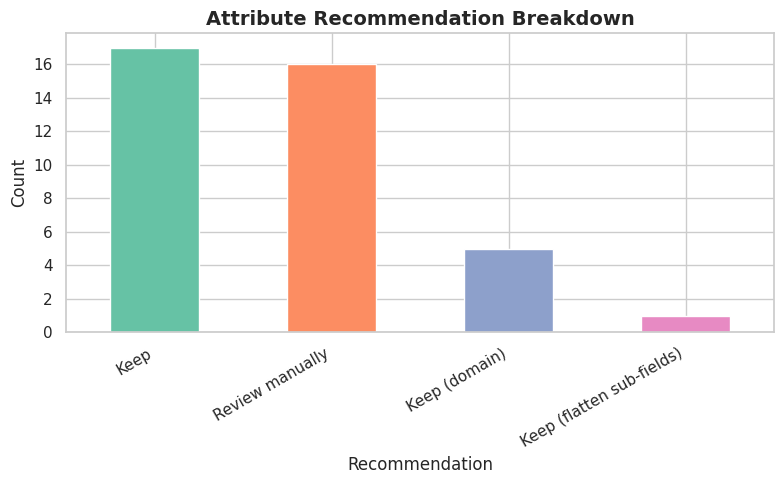

In [0]:
rec_counts = attr_profile_pd["Recommendation"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
rec_counts.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", len(rec_counts)))
ax.set_title("Attribute Recommendation Breakdown")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Rating & Review Analysis
Core inputs to **M2 (Business Health Score)** and **M4 (Review Trust)**.

### 6.1 Star Rating Distribution

stars,count
1.0,1986
1.5,4932
2.0,9527
2.5,14316
3.0,18453
3.5,26519
4.0,31125
4.5,27181
5.0,16307


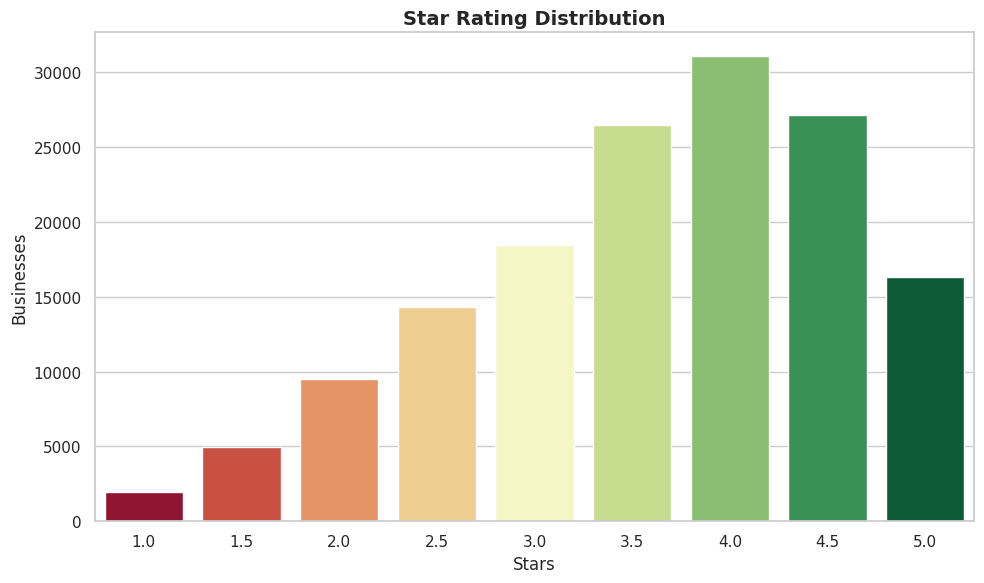

Average star rating across all businesses: 3.597


In [0]:
stars_pd = business_flat.groupBy("stars").count().orderBy("stars").toPandas()
display(spark.createDataFrame(stars_pd))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=stars_pd, x="stars", y="count", ax=ax, palette="RdYlGn", hue="stars", legend=False)
ax.set_title("Star Rating Distribution")
ax.set_xlabel("Stars")
ax.set_ylabel("Businesses")
plt.tight_layout()
plt.show()

avg_stars = business_flat.selectExpr("avg(stars) as avg_stars").collect()[0]["avg_stars"]
print(f"Average star rating across all businesses: {avg_stars:.3f}")


### 6.2 Review Count Distribution (heavily right-skewed — log scale needed)

summary,review_count
count,150346
mean,44.86656113232144
stddev,121.12013570117078
min,5
max,7568


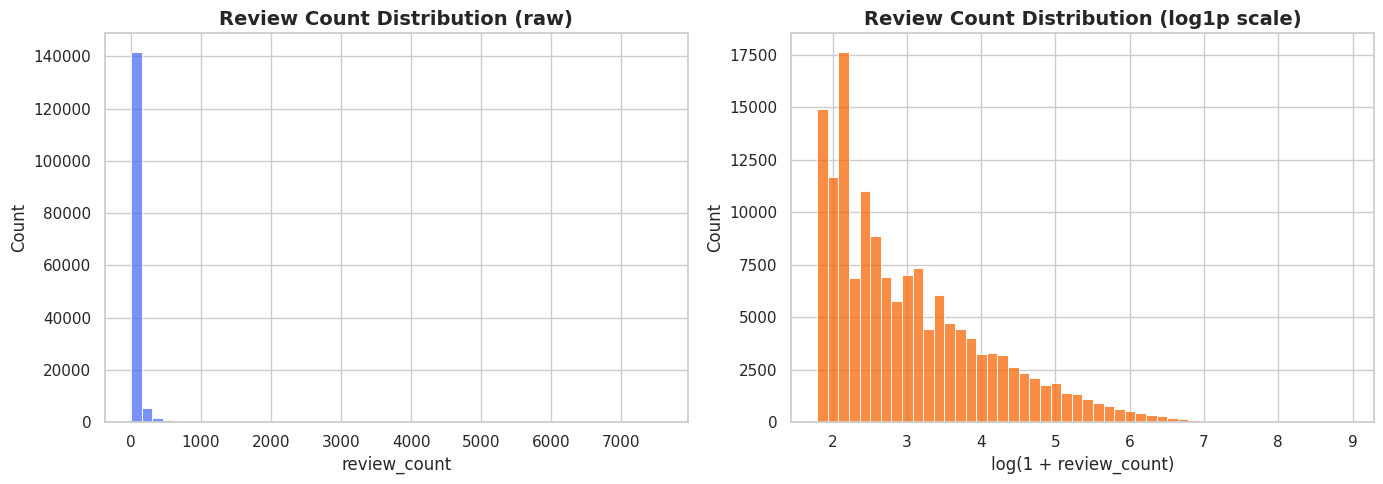

In [0]:
review_count_pd = business_flat.select("review_count").toPandas()
display(business_flat.select("review_count").describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(review_count_pd["review_count"], bins=50, ax=axes[0], color="#4c6ef5")
axes[0].set_title("Review Count Distribution (raw)")

sns.histplot(np.log1p(review_count_pd["review_count"]), bins=50, ax=axes[1], color="#f76707")
axes[1].set_title("Review Count Distribution (log1p scale)")
axes[1].set_xlabel("log(1 + review_count)")
plt.tight_layout()
plt.show()


### 6.3 Most-Reviewed Businesses (Top 20)

In [0]:
display(
    business_flat.select("name", "city", "state", "review_count", "stars")
    .orderBy(desc("review_count")).limit(20)
)


name,city,state,review_count,stars
Acme Oyster House,New Orleans,LA,7568,4.0
Oceana Grill,New Orleans,LA,7400,4.0
Hattie B’s Hot Chicken - Nashville,Nashville,TN,6093,4.5
Reading Terminal Market,Philadelphia,PA,5721,4.5
Ruby Slipper - New Orleans,New Orleans,LA,5193,4.5
Mother's Restaurant,New Orleans,LA,5185,3.5
Royal House,New Orleans,LA,5070,4.0
Commander's Palace,New Orleans,LA,4876,4.5
Luke,New Orleans,LA,4554,4.0
Cochon,New Orleans,LA,4421,4.0


### 6.4 Rating vs Review Volume — is a high star rating actually backed by evidence?

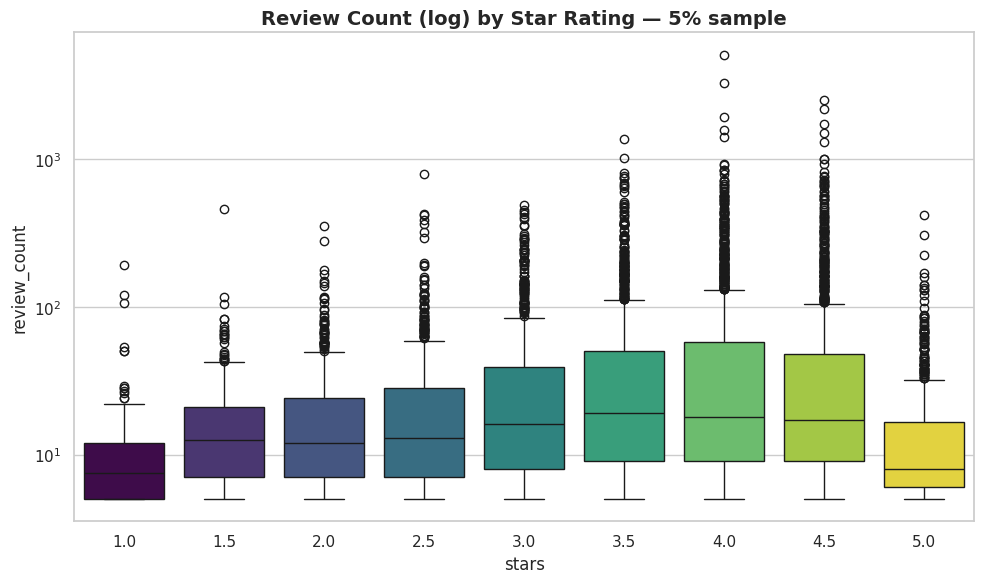

In [0]:
sample_pd = business_flat.select("stars", "review_count").sample(fraction=0.05, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=sample_pd, x="stars", y="review_count", ax=ax, palette="viridis", hue="stars", legend=False)
ax.set_yscale("log")
ax.set_title("Review Count (log) by Star Rating — 5% sample")
plt.tight_layout()
plt.show()


## 7. Operational Analysis
These become direct features for **M2 (Business Health)** and **M3 (Demand Forecasting)**.

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804632-1779660828:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, y=m, x="count", ax=axes[plot_i], palette="crest")
/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804632-1779660828:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, y=m, x="count", ax=axes[plot_i], palette="crest")
/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804632-1779660828:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vc, 

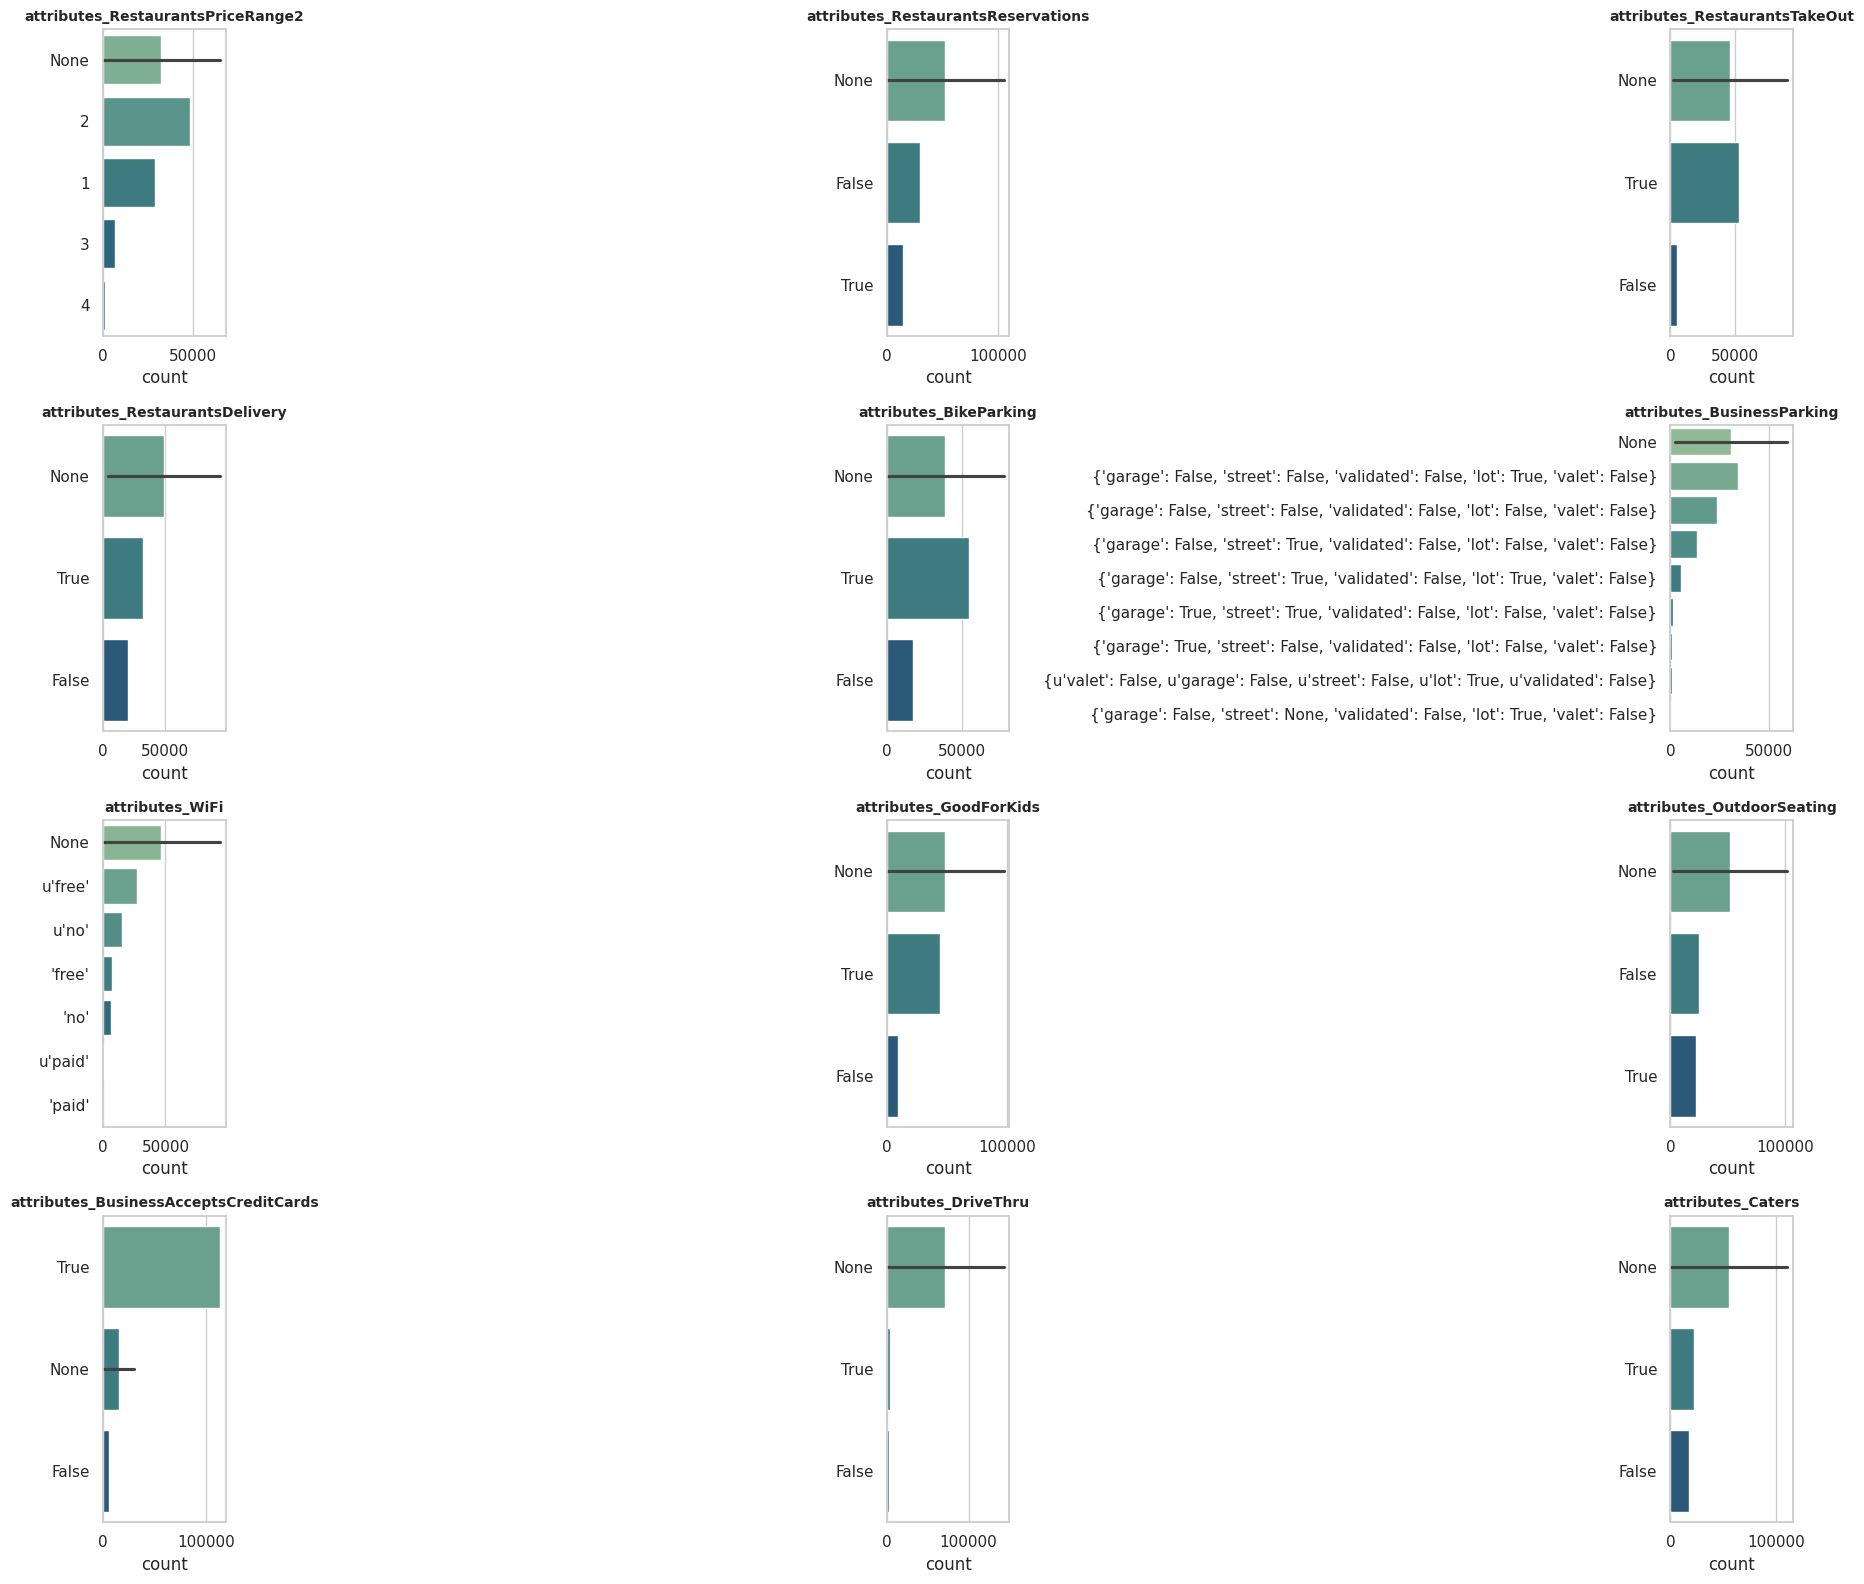

Plotted 12 operational attribute distributions.


In [0]:
# Helper function to find columns by keyword
def find_cols(keyword, columns=None):
    columns = columns or business_flat.columns
    return [c for c in columns if keyword.lower() in c.lower()]

operational_keywords = [
    "PriceRange", "Reservations", "TakeOut", "Delivery", "Parking",
    "WiFi", "GoodForKids", "OutdoorSeating", "CreditCards", "DriveThru", "Caters"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
plot_i = 0

for kw in operational_keywords:
    matches = find_cols(kw)
    for m in matches:
        if plot_i >= len(axes):
            break
        vc = business_flat.groupBy(m).count().orderBy(desc("count")).limit(10).toPandas()
        vc[m] = vc[m].astype(str)
        sns.barplot(data=vc, y=m, x="count", ax=axes[plot_i], palette="crest")
        axes[plot_i].set_title(m, fontsize=10)
        axes[plot_i].set_ylabel("")
        plot_i += 1

for j in range(plot_i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
print(f"Plotted {plot_i} operational attribute distributions.")


### 7.1 Opening Hours Coverage (which days are most commonly recorded?)

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804634-2684228915:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hours_pd, x="Day", y="Coverage_%", ax=ax, palette="mako")


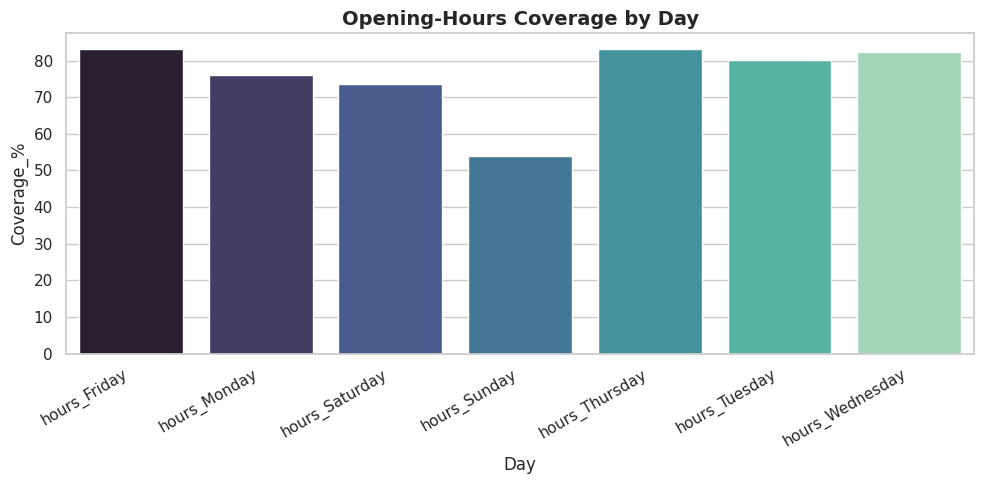

In [0]:
# Extract hours_* columns
hours_columns = sorted([c for c in business_flat.columns if c.startswith("hours_")])

if hours_columns:
    hours_missing = []
    for c in hours_columns:
        non_null = business_flat.filter(col(c).isNotNull()).count()
        hours_missing.append((c, round(non_null * 100 / total_rows, 2)))
    hours_pd = pd.DataFrame(hours_missing, columns=["Day", "Coverage_%"])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=hours_pd, x="Day", y="Coverage_%", ax=ax, palette="mako")
    ax.set_title("Opening-Hours Coverage by Day")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hours_* columns found in this schema.")


## 8. Feature Relationships (Attribute vs Rating / Reviews)
Answers concrete business questions: *does offering WiFi correlate with higher ratings? Does
price range affect review volume?* These relationships justify which attributes make it into
the Gold-layer Business Health Score (M2).

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804636-2724477051:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_pd, x=c, y="avg_stars", ax=axes[plot_i], palette="RdYlGn")
/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804636-2724477051:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_pd, x=c, y="avg_stars", ax=axes[plot_i], palette="RdYlGn")
/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804636-2724477051:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns

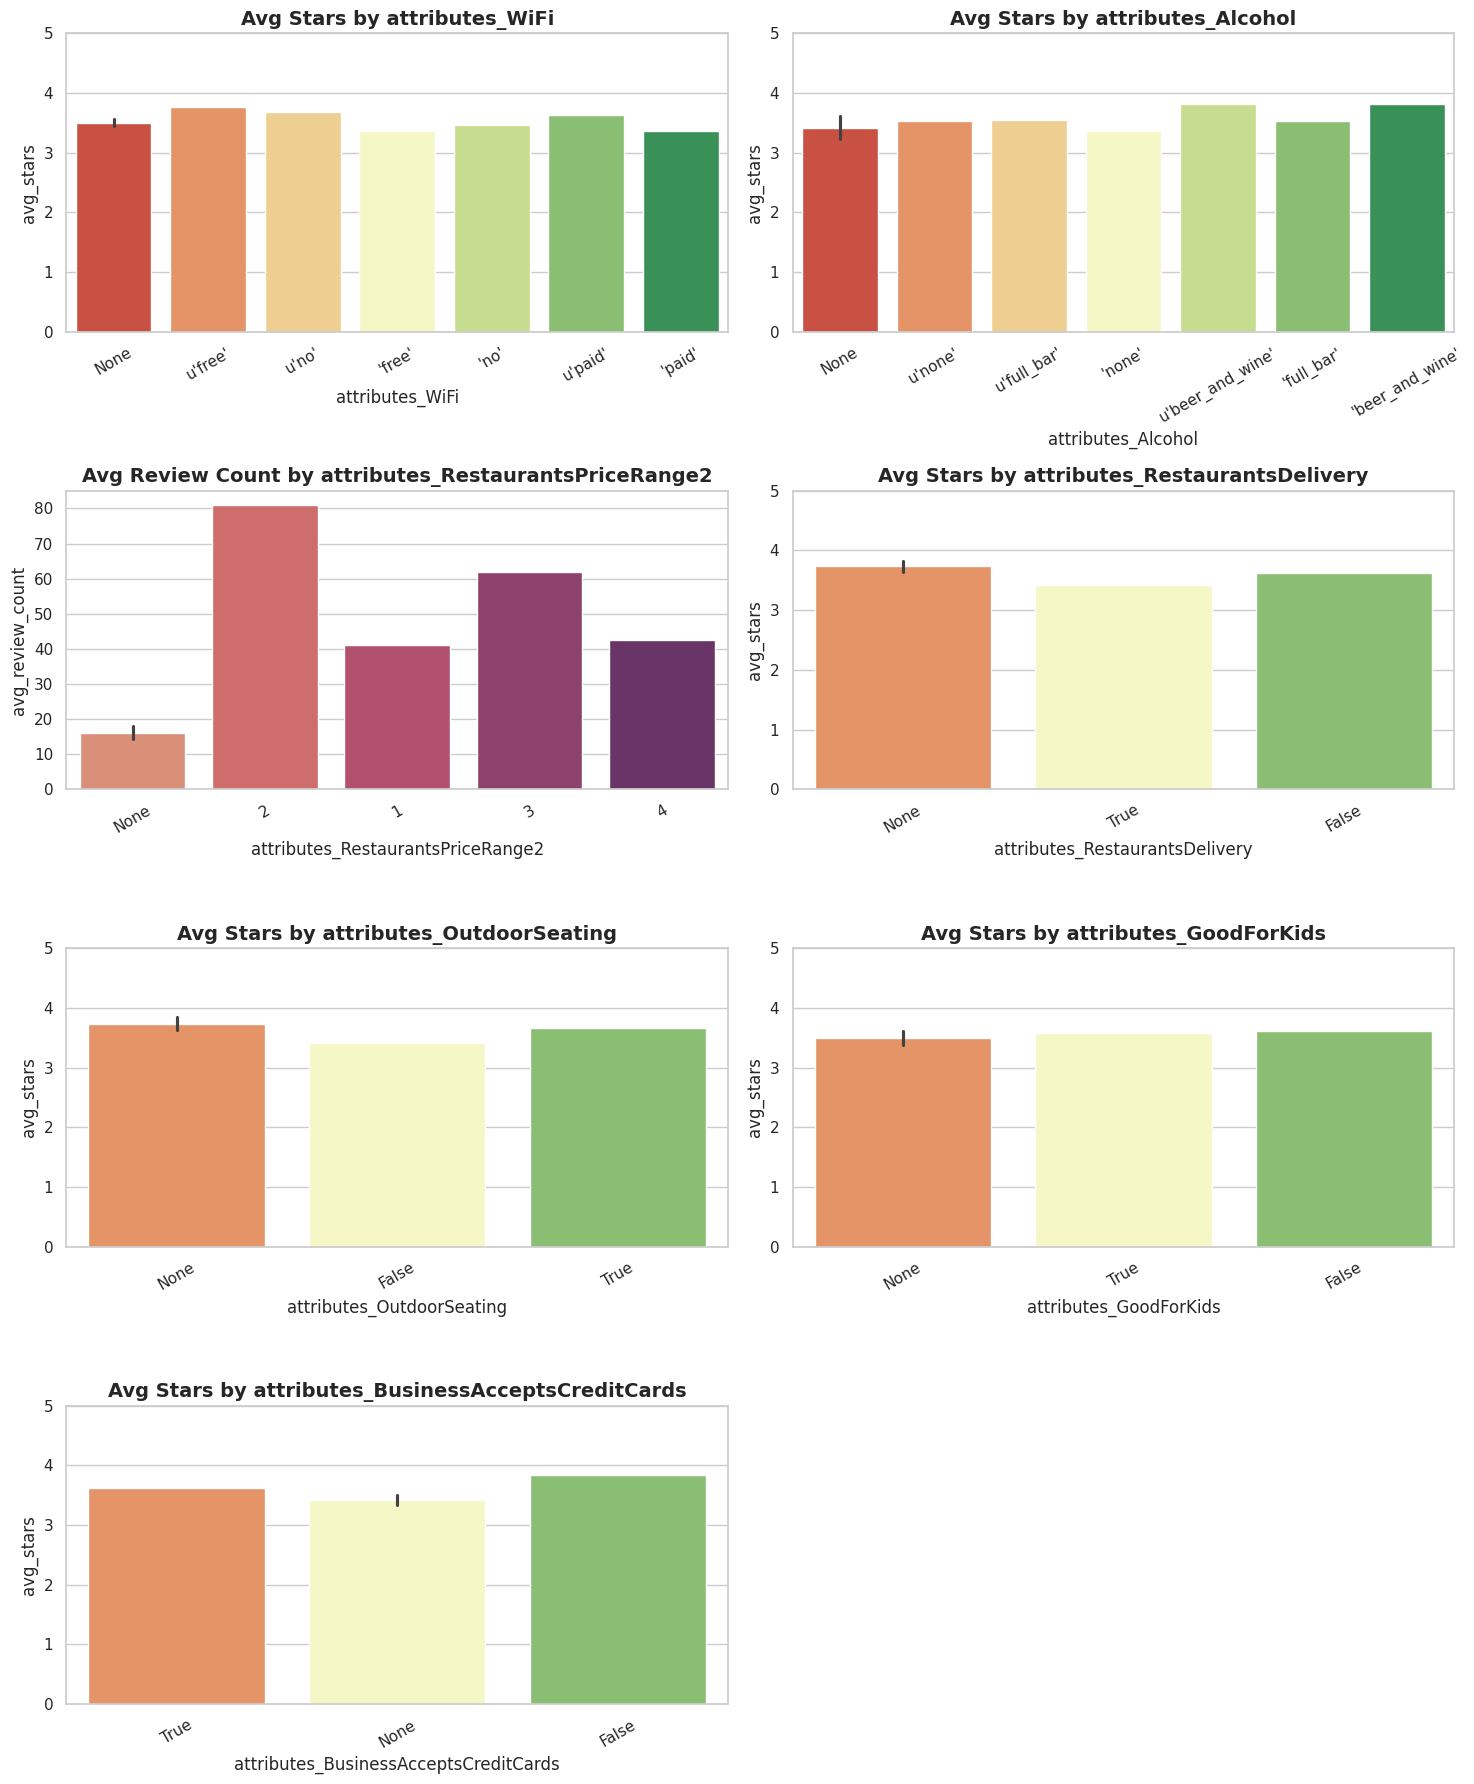

Rendered 7 attribute-vs-outcome relationships (attributes not found in schema were skipped).


In [0]:
# Helper function to find single column by keyword
def find_col(keyword, columns=None):
    columns = columns or business_flat.columns
    matches = [c for c in columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

relationship_specs = [
    ("WiFi", "avg_stars"),
    ("Alcohol", "avg_stars"),
    ("PriceRange", "avg_review_count"),
    ("Delivery", "avg_stars"),
    ("OutdoorSeating", "avg_stars"),
    ("GoodForKids", "avg_stars"),
    ("CreditCards", "avg_stars"),
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
plot_i = 0

for keyword, metric in relationship_specs:
    c = find_col(keyword)
    if c is None:
        continue
    if metric == "avg_stars":
        agg_pd = (
            business_flat.groupBy(c)
            .agg(spround(avg("stars"), 3).alias("avg_stars"), count("*").alias("n"))
            .orderBy(desc("n")).limit(10).toPandas()
        )
        agg_pd[c] = agg_pd[c].astype(str)
        sns.barplot(data=agg_pd, x=c, y="avg_stars", ax=axes[plot_i], palette="RdYlGn")
        axes[plot_i].set_title(f"Avg Stars by {c}")
        axes[plot_i].set_ylim(0, 5)
    else:
        agg_pd = (
            business_flat.groupBy(c)
            .agg(spround(avg("review_count"), 1).alias("avg_review_count"), count("*").alias("n"))
            .orderBy(desc("n")).limit(10).toPandas()
        )
        agg_pd[c] = agg_pd[c].astype(str)
        sns.barplot(data=agg_pd, x=c, y="avg_review_count", ax=axes[plot_i], palette="flare")
        axes[plot_i].set_title(f"Avg Review Count by {c}")

    axes[plot_i].tick_params(axis="x", rotation=30)
    plot_i += 1

for j in range(plot_i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
print(f"Rendered {plot_i} attribute-vs-outcome relationships (attributes not found in schema were skipped).")


## 9. Geographic Analysis
Feeds **M3 (regional demand)** and location-based Business Health benchmarking in M2.

### 9.1 Average Rating by State

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804639-4214463508:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stars_pd.head(20), y="state", x="avg_stars", ax=ax, palette="RdYlGn")


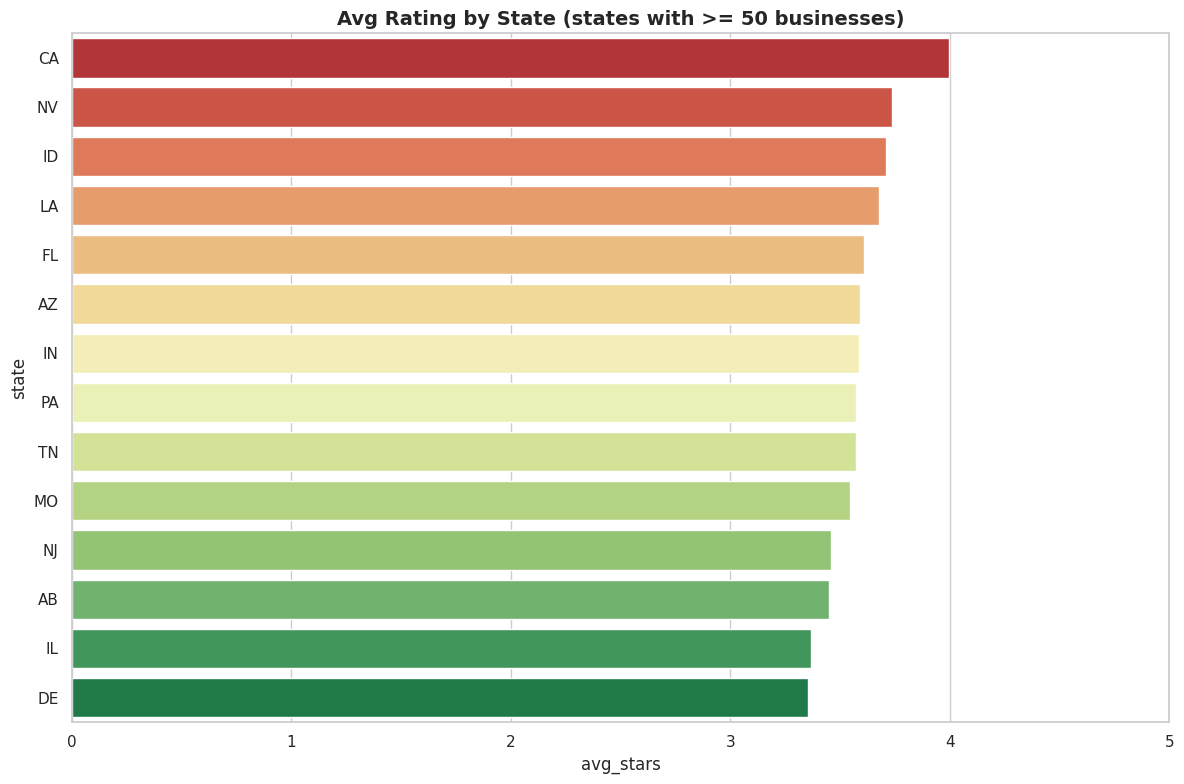

In [0]:
state_stars_pd = (
    business_flat.groupBy("state")
    .agg(spround(avg("stars"), 3).alias("avg_stars"), count("*").alias("n"))
    .filter(col("n") >= 50)
    .orderBy(desc("avg_stars"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=state_stars_pd.head(20), y="state", x="avg_stars", ax=ax, palette="RdYlGn")
ax.set_title("Avg Rating by State (states with >= 50 businesses)")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()


### 9.2 Average Review Count by State

/home/spark-9bc572a8-5281-484d-aa90-d6/.ipykernel/305/command-7848867075804641-3745520339:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_reviews_pd.head(20), y="state", x="avg_review_count", ax=ax, palette="flare")


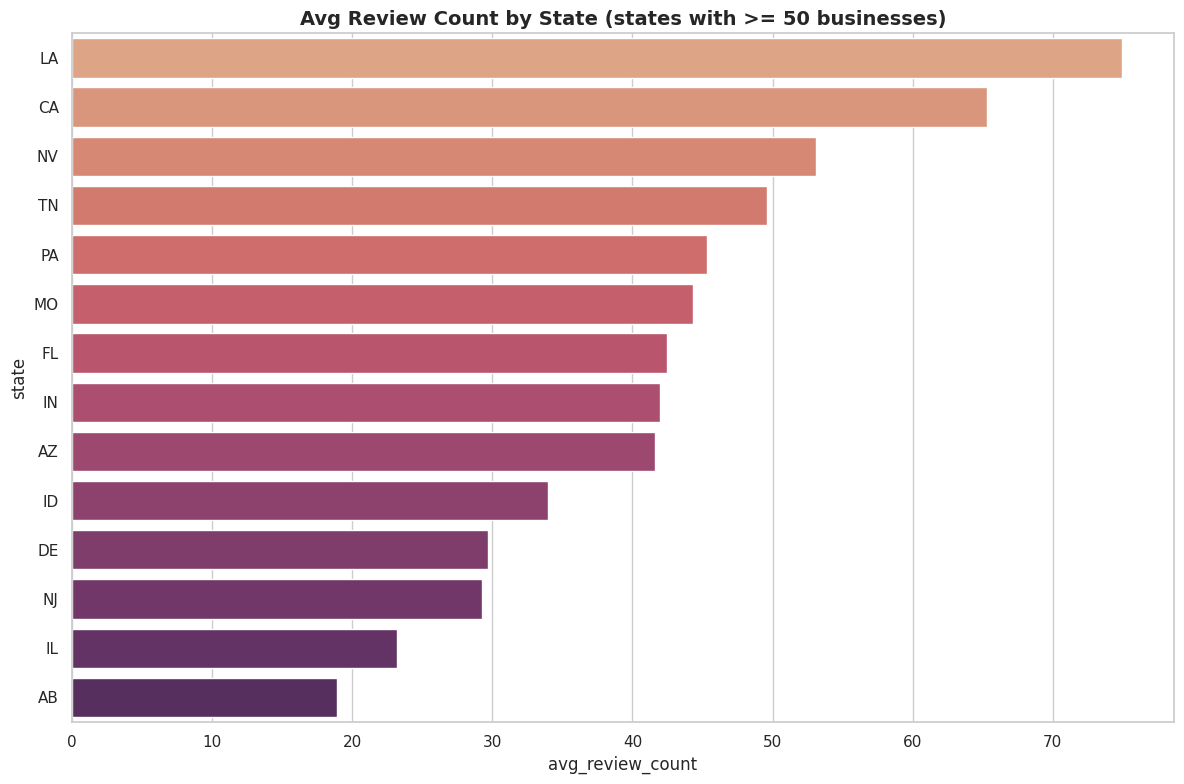

In [0]:
state_reviews_pd = (
    business_flat.groupBy("state")
    .agg(spround(avg("review_count"), 1).alias("avg_review_count"), count("*").alias("n"))
    .filter(col("n") >= 50)
    .orderBy(desc("avg_review_count"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=state_reviews_pd.head(20), y="state", x="avg_review_count", ax=ax, palette="flare")
ax.set_title("Avg Review Count by State (states with >= 50 businesses)")
plt.tight_layout()
plt.show()


### 9.3 Business Location Density (lat/long scatter)

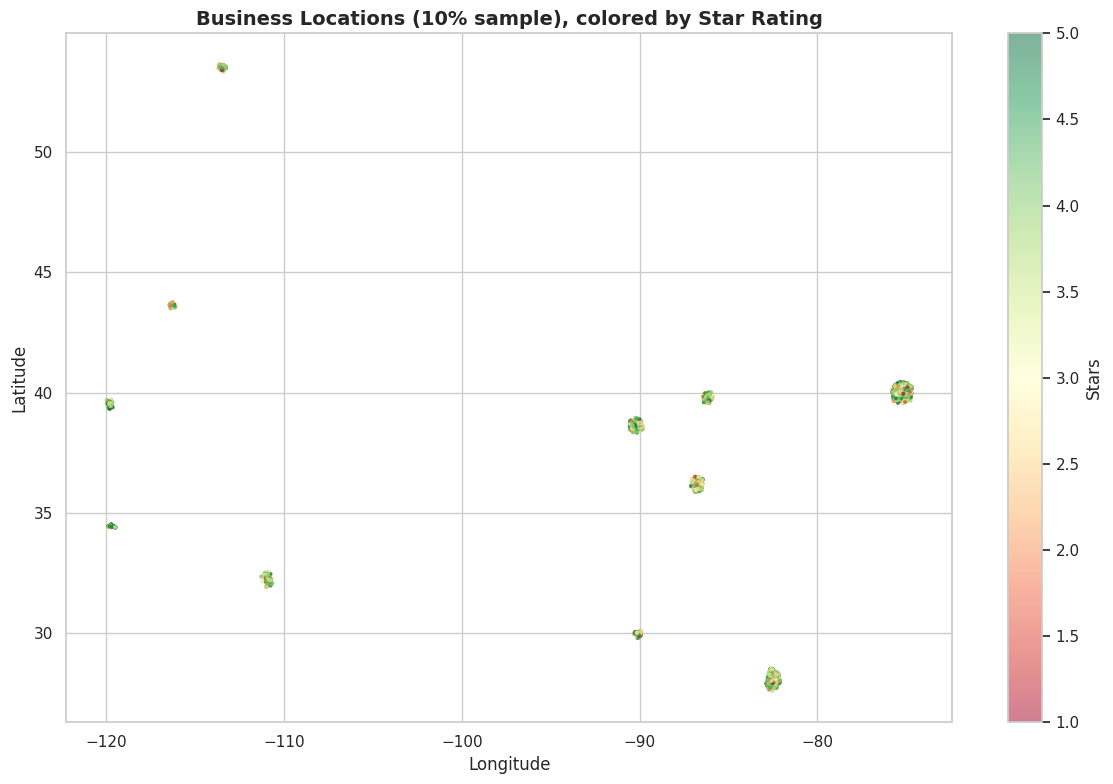

In [0]:
geo_pd = business_flat.select("latitude", "longitude", "stars").sample(fraction=0.1, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(geo_pd["longitude"], geo_pd["latitude"], c=geo_pd["stars"],
                 cmap="RdYlGn", s=4, alpha=0.5)
ax.set_title("Business Locations (10% sample), colored by Star Rating")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label="Stars")
plt.tight_layout()
plt.show()


## 10. Correlation Analysis
Numeric relationships among `stars`, `review_count`, `latitude`, `longitude`, and `is_open`.

Numeric columns detected: ['is_open', 'latitude', 'longitude', 'review_count', 'stars']


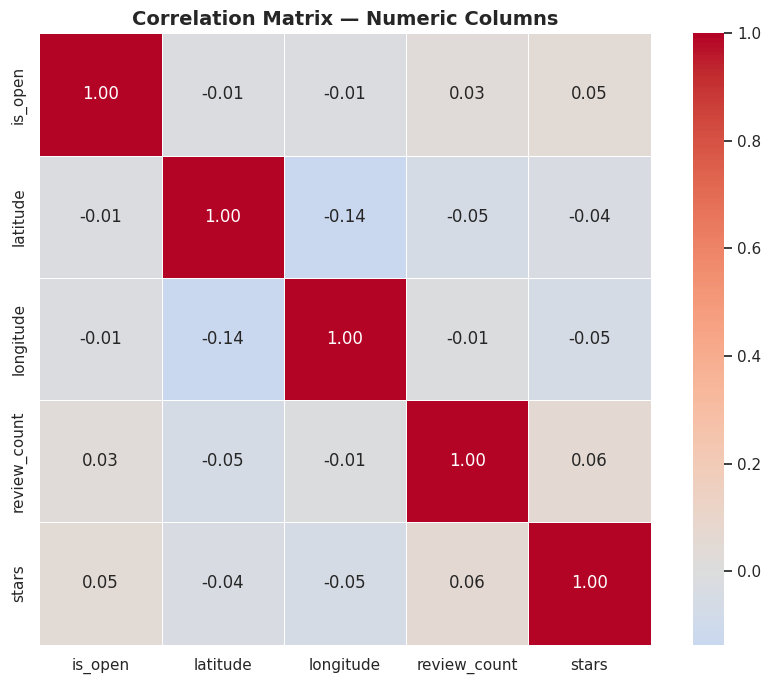

Pearson correlation (stars, review_count): 0.0599


In [0]:
numeric_candidates = [f.name for f in business_flat.schema.fields
                       if isinstance(f.dataType, NumericType)]
print(f"Numeric columns detected: {numeric_candidates}")

corr_pd = business_flat.select(numeric_candidates).sample(fraction=0.2, seed=42).toPandas()
corr_matrix = corr_pd.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title("Correlation Matrix — Numeric Columns")
plt.tight_layout()
plt.show()

stars_review_corr = business_flat.stat.corr("stars", "review_count")
print(f"Pearson correlation (stars, review_count): {stars_review_corr:.4f}")


## 11. BI Readiness / Silver-Layer Decision Report
This is the final, authoritative table: one row per column with data type, missingness,
business importance and the transformation action to take when building the Silver layer.

In [0]:
# Base decision table from schema + missingness
readiness_rows = []
schema_types = {f.name: str(f.dataType) for f in business_flat.schema.fields}

for _, row in missing_df.iterrows():
    c = row["Column"]
    dtype = schema_types.get(c, "unknown")

    if c in ("business_id", "name", "stars", "review_count", "is_open", "city", "state", "categories", "latitude", "longitude"):
        importance, module, action = "High", "M2,M3", "Keep"
    elif c.startswith("attributes_"):
        match = attr_profile_pd.loc[attr_profile_pd["Attribute"] == c]
        if not match.empty:
            importance = "High" if match["Coverage_%"].values[0] > 30 else "Domain-dependent"
            module = match["Business_Modules"].values[0]
            action = match["Recommendation"].values[0]
        else:
            importance, module, action = "Unknown", "TBD", "Review"
    elif c.startswith("hours_"):
        importance, module, action = "Medium", "M3", "Keep (parse to numeric open/close)"
    elif c in constant_cols:
        importance, module, action = "None", "-", "Drop (constant)"
    else:
        importance, module, action = "Low", "-", "Review"

    readiness_rows.append((c, dtype, row["Missing_%"], importance, module, action))

readiness_df = pd.DataFrame(readiness_rows, columns=[
    "Column", "Data_Type", "Missing_%", "Business_Importance", "Module", "Action"
])

display(spark.createDataFrame(readiness_df))


Column,Data_Type,Missing_%,Business_Importance,Module,Action
attributes_RestaurantsCounterService,StringType(),99.99,Domain-dependent,TBD,Review manually
attributes_DietaryRestrictions,StringType(),99.98,Domain-dependent,TBD,Review manually
attributes_Open24Hours,StringType(),99.97,Domain-dependent,TBD,Review manually
attributes_AgesAllowed,StringType(),99.91,Domain-dependent,TBD,Review manually
attributes_HairSpecializesIn,StringType(),99.29,Domain-dependent,Domain-specific,Keep (domain)
attributes_BYOBCorkage,StringType(),99.04,Domain-dependent,TBD,Review manually
attributes_Corkage,StringType(),97.64,Domain-dependent,TBD,Review manually
attributes_BYOB,StringType(),97.04,Domain-dependent,TBD,Review manually
attributes_Smoking,StringType(),96.96,Domain-dependent,M2,Keep
attributes_GoodForDancing,StringType(),96.92,Domain-dependent,Domain-specific,Keep (domain)


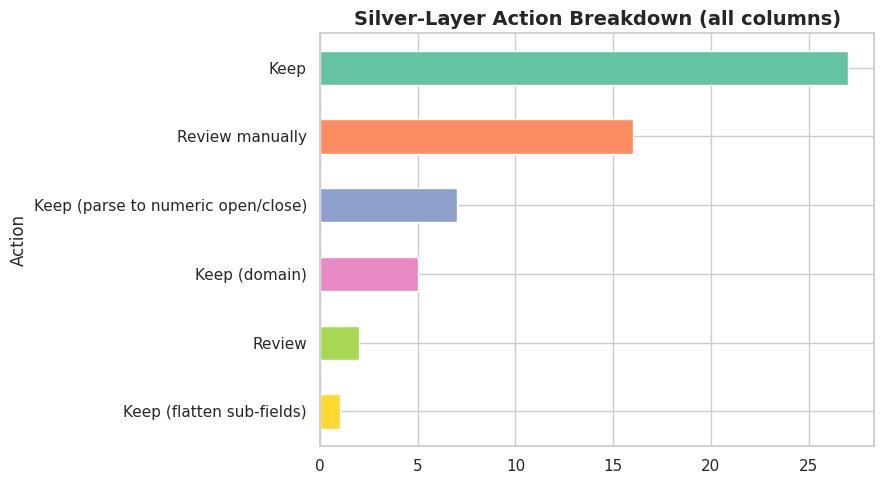

In [0]:
action_counts = readiness_df["Action"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
action_counts.plot(kind="barh", ax=ax, color=sns.color_palette("Set2", len(action_counts)))
ax.set_title("Silver-Layer Action Breakdown (all columns)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 12. Executive Summary of Findings
Auto-generated from the metrics computed above — re-run top to bottom and this cell will
reflect the current numbers.

In [0]:
print("=" * 70)
print("EXECUTIVE SUMMARY — YELP BUSINESS DATASET EDA")
print("=" * 70)
print(f"""
DATASET
  - Rows: {total_rows:,} | Columns: {total_cols:,} (post-flatten)
  - Attribute columns: {len(attribute_columns)} | Hours columns: {len(hours_columns)}

DATA QUALITY
  - Duplicate business_id groups: {dup_id_count}
  - Exact duplicate rows: {total_rows - distinct_rows:,}
  - Constant columns (zero information): {len(constant_cols)} -> {constant_cols}

BUSINESS PROFILE
  - Closed business share: {closed_pct}%
  - Average star rating: {avg_stars:.3f}
  - Stars/Review-Count correlation: {stars_review_corr:.4f}

ATTRIBUTE PROFILING
  - Attributes with >50% coverage (safe as general features):
      {attr_profile_pd.loc[attr_profile_pd['Coverage_%'] > 50, 'Attribute'].tolist()}
  - Attributes recommended as domain-specific only:
      {attr_profile_pd.loc[attr_profile_pd['Recommendation'].astype(str).str.contains('domain', case=False), 'Attribute'].tolist()}

NEXT STEPS
  1. Apply the Silver-layer Action column (Section 11) to build business_silver.
  2. Parse hours_* into numeric open/close + weekly operating-hours feature for M3.
  3. Flatten remaining nested attribute structs (e.g. BusinessParking sub-fields) if not already atomic.
  4. Join category_df (exploded categories) into the Gold category-performance mart for M1/M5.
  5. Carry forward business_id, stars, review_count, is_open, state/city, categories, and the
     'Keep' attributes from Section 11 into the Silver table; drop constant + near-100%-missing
     non-domain attributes.
""")


EXECUTIVE SUMMARY — YELP BUSINESS DATASET EDA

DATASET
  - Rows: 150,346 | Columns: 58 (post-flatten)
  - Attribute columns: 39 | Hours columns: 7

DATA QUALITY
  - Duplicate business_id groups: 0
  - Exact duplicate rows: 0
  - Constant columns (zero information): 0 -> []

BUSINESS PROFILE
  - Closed business share: 20.38%
  - Average star rating: 3.597
  - Stars/Review-Count correlation: 0.0599

ATTRIBUTE PROFILING
  - Attributes with >50% coverage (safe as general features):
      ['attributes_BusinessAcceptsCreditCards', 'attributes_BusinessParking', 'attributes_RestaurantsPriceRange2']
  - Attributes recommended as domain-specific only:
      ['attributes_Music', 'attributes_AcceptsInsurance', 'attributes_CoatCheck', 'attributes_GoodForDancing', 'attributes_HairSpecializesIn']

NEXT STEPS
  1. Apply the Silver-layer Action column (Section 11) to build business_silver.
  2. Parse hours_* into numeric open/close + weekly operating-hours feature for M3.
  3. Flatten remaining nested 

##Section 14 — Cleaning Strategy
Objective:
Prepare the flattened Business dataset for the Silver layer.

Cleaning Rules

1. Trim leading/trailing spaces from string columns.
2. Standardize column names.
3. Validate numeric columns.
4. Validate latitude/longitude.
5. Preserve nullable business attributes.
6. Remove duplicate business_id records if found.
7. Convert data types where required.
8. Store cleaned dataset as Parquet.

Section 15 — Create Silver Working DataFrame

In [0]:
# Create a copy for Silver layer preparation

business_silver_df = business_flat

Section 16 — Trim All String Columns

Import if you haven't already:

In [0]:
from pyspark.sql.types import StringType
from pyspark.sql.functions import trim, col

Now trim every string column:


In [0]:
string_columns = [
    field.name
    for field in business_silver_df.schema.fields
    if isinstance(field.dataType, StringType)
]

print(f"String Columns Found : {len(string_columns)}")
print(string_columns)

String Columns Found : 53
['address', 'business_id', 'categories', 'city', 'name', 'postal_code', 'state', 'attributes_AcceptsInsurance', 'attributes_AgesAllowed', 'attributes_Alcohol', 'attributes_Ambience', 'attributes_BYOB', 'attributes_BYOBCorkage', 'attributes_BestNights', 'attributes_BikeParking', 'attributes_BusinessAcceptsBitcoin', 'attributes_BusinessAcceptsCreditCards', 'attributes_BusinessParking', 'attributes_ByAppointmentOnly', 'attributes_Caters', 'attributes_CoatCheck', 'attributes_Corkage', 'attributes_DietaryRestrictions', 'attributes_DogsAllowed', 'attributes_DriveThru', 'attributes_GoodForDancing', 'attributes_GoodForKids', 'attributes_GoodForMeal', 'attributes_HairSpecializesIn', 'attributes_HappyHour', 'attributes_HasTV', 'attributes_Music', 'attributes_NoiseLevel', 'attributes_Open24Hours', 'attributes_OutdoorSeating', 'attributes_RestaurantsAttire', 'attributes_RestaurantsCounterService', 'attributes_RestaurantsDelivery', 'attributes_RestaurantsGoodForGroups', 'a

In [0]:
for c in string_columns:
    business_silver_df = business_silver_df.withColumn(
        c,
        trim(col(c))
    )

print("✓ All string columns trimmed.")

✓ All string columns trimmed.


Section 17 — Standardize Column Names

Your flattened columns probably look like:

attributes_WiFi

attributes_BikeParking

hours_Monday


Let's standardize them.


In [0]:
import re

def standardize_column_name(column_name):

    column_name = column_name.strip()

    column_name = column_name.replace(" ", "_")

    column_name = column_name.replace("-", "_")

    column_name = re.sub(r"[^a-zA-Z0-9_]", "", column_name)

    column_name = re.sub(r"_+", "_", column_name)

    return column_name.lower()

In [0]:
#Rename every column.

for old_col in business_silver_df.columns:

    new_col = standardize_column_name(old_col)

    if old_col != new_col:
        business_silver_df = business_silver_df.withColumnRenamed(
            old_col,
            new_col
        )

print("✓ Column names standardized.")

✓ Column names standardized.


In [0]:
business_silver_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- attributes_acceptsinsurance: string (nullable = true)
 |-- attributes_agesallowed: string (nullable = true)
 |-- attributes_alcohol: string (nullable = true)
 |-- attributes_ambience: string (nullable = true)
 |-- attributes_byob: string (nullable = true)
 |-- attributes_byobcorkage: string (nullable = true)
 |-- attributes_bestnights: string (nullable = true)
 |-- attributes_bikeparking: string (nullable = true)
 |-- attributes_businessacceptsbitcoin: string (nullable = true)
 |-- attributes_businessacceptscred

Section 18 — Data Type Validation
Lets inspect


In [0]:
from pyspark.sql.types import *

datatype_summary = []

for field in business_silver_df.schema.fields:

    datatype_summary.append((
        field.name,
        str(field.dataType)
    ))

display(
    spark.createDataFrame(
        datatype_summary,
        ["Column","Current_DataType"]
    )
)

Column,Current_DataType
address,StringType()
business_id,StringType()
categories,StringType()
city,StringType()
is_open,LongType()
latitude,DoubleType()
longitude,DoubleType()
name,StringType()
postal_code,StringType()
review_count,LongType()


# 17. Value Validation

## Objective

Validate critical business fields against predefined business rules before storing the dataset in the Silver layer.

Validation includes:

- Primary Key validation
- Rating validation
- Geographic coordinate validation
- Review count validation
- Business status validation

17.1 Primary Key Validation

A business cannot exist without a business_id.

In [0]:
from pyspark.sql.functions import col

business_silver_df.filter(
    col("business_id").isNull()
).count()

0

17.2 Business Name Validation

In [0]:
business_silver_df.filter(
    col("business_id") == ""
).count()

0

In [0]:
business_silver_df.filter(
    col("name") == ""
).count()

0

17.3 Stars Validation

Ratings should be between 1 and 5.

In [0]:
invalid_stars = business_silver_df.filter(
    (col("stars") < 1) |
    (col("stars") > 5)
)

print("Invalid Ratings :", invalid_stars.count())

Invalid Ratings : 0


17.4 Review Count Validation

Review count cannot be negative.

In [0]:
invalid_reviews = business_silver_df.filter(
    col("review_count") < 0
)

print("Negative Review Counts :", invalid_reviews.count())

Negative Review Counts : 0


17.5 Latitude Validation

In [0]:
invalid_lat = business_silver_df.filter(
    (col("latitude") < -90) |
    (col("latitude") > 90)
)

print("Invalid Latitude :", invalid_lat.count())

Invalid Latitude : 0


17.6 Longitude Validation

In [0]:
invalid_long = business_silver_df.filter(
    (col("longitude") < -180) |
    (col("longitude") > 180)
)

print("Invalid Longitude :", invalid_long.count())

Invalid Longitude : 0


17.7 Business Status Validation

In [0]:
business_silver_df.groupBy("is_open").count().show()

+-------+------+
|is_open| count|
+-------+------+
|      1|119698|
|      0| 30648|
+-------+------+



17.8 Postal Code Validation (Recommended)

In [0]:
business_silver_df.filter(
    (col("postal_code").isNotNull()) &
    (trim(col("postal_code")) == "")
).count()

73

17.9 State Validation

Find the distinct states to ensure there are no unexpected values.

In [0]:
business_silver_df.select("state") \
    .distinct() \
    .orderBy("state") \
    .show(100, truncate=False)

+-----+
|state|
+-----+
|AB   |
|AZ   |
|CA   |
|CO   |
|DE   |
|FL   |
|HI   |
|ID   |
|IL   |
|IN   |
|LA   |
|MA   |
|MI   |
|MO   |
|MT   |
|NC   |
|NJ   |
|NV   |
|PA   |
|SD   |
|TN   |
|TX   |
|UT   |
|VI   |
|VT   |
|WA   |
|XMS  |
+-----+



17.10 Categories Validation

In [0]:
business_silver_df.filter(
    col("categories").isNull()
).count()

103

In [0]:
validation_results = [
    ("business_id Null", business_silver_df.filter(col("business_id").isNull()).count()),
    ("business_id Empty", business_silver_df.filter(col("business_id") == "").count()),
    ("Invalid Stars", business_silver_df.filter((col("stars") < 1) | (col("stars") > 5)).count()),
    ("Negative Review Count", business_silver_df.filter(col("review_count") < 0).count()),
    ("Invalid Latitude", business_silver_df.filter((col("latitude") < -90) | (col("latitude") > 90)).count()),
    ("Invalid Longitude", business_silver_df.filter((col("longitude") < -180) | (col("longitude") > 180)).count())
]

validation_df = spark.createDataFrame(validation_results, ["Validation", "Issue_Count"])

display(validation_df)

Validation,Issue_Count
business_id Null,0
business_id Empty,0
Invalid Stars,0
Negative Review Count,0
Invalid Latitude,0
Invalid Longitude,0


# 19. Null Handling

## Objective

Review null values and apply only business-approved handling rules.

### Rules

- Preserve meaningful NULL values.
- Do not replace NULLs with arbitrary defaults.
- Convert empty strings to NULL where appropriate.
- Document high-null columns for downstream consumers.

In [0]:
#Convert empty strings to NULL for all string columns:

from pyspark.sql.functions import when, trim, col
from pyspark.sql.types import StringType

for field in business_silver_df.schema.fields:
    if isinstance(field.dataType, StringType):
        business_silver_df = business_silver_df.withColumn(
            field.name,
            when(trim(col(field.name)) == "", None)
            .otherwise(col(field.name))
        )

In [0]:
#verify

from pyspark.sql.functions import count, when

null_summary = business_silver_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in business_silver_df.columns
])

display(null_summary)

address,business_id,categories,city,is_open,latitude,longitude,name,postal_code,review_count,stars,state,attributes_acceptsinsurance,attributes_agesallowed,attributes_alcohol,attributes_ambience,attributes_byob,attributes_byobcorkage,attributes_bestnights,attributes_bikeparking,attributes_businessacceptsbitcoin,attributes_businessacceptscreditcards,attributes_businessparking,attributes_byappointmentonly,attributes_caters,attributes_coatcheck,attributes_corkage,attributes_dietaryrestrictions,attributes_dogsallowed,attributes_drivethru,attributes_goodfordancing,attributes_goodforkids,attributes_goodformeal,attributes_hairspecializesin,attributes_happyhour,attributes_hastv,attributes_music,attributes_noiselevel,attributes_open24hours,attributes_outdoorseating,attributes_restaurantsattire,attributes_restaurantscounterservice,attributes_restaurantsdelivery,attributes_restaurantsgoodforgroups,attributes_restaurantspricerange2,attributes_restaurantsreservations,attributes_restaurantstableservice,attributes_restaurantstakeout,attributes_smoking,attributes_wheelchairaccessible,attributes_wifi,hours_friday,hours_monday,hours_saturday,hours_sunday,hours_thursday,hours_tuesday,hours_wednesday
5127,0,103,0,0,0,0,0,73,0,0,0,144633,150217,107157,106067,145895,148902,144652,77708,132916,30581,59261,108007,110219,144762,146793,150315,132062,142586,145718,96971,121259,149281,135175,105262,142825,112353,150307,101544,111091,150327,94064,106176,65032,105099,130364,90489,145779,121393,93432,25347,35872,39576,69174,25148,29715,26575


# 20. Duplicate Handling

## Objective

Ensure one record exists for every Business ID.

Primary Key

business_id

In [0]:
before = business_silver_df.count()

business_silver_df = business_silver_df.dropDuplicates(["business_id"])

after = business_silver_df.count()

print(f"Rows Before : {before}")
print(f"Rows After  : {after}")
print(f"Duplicates Removed : {before-after}")

Rows Before : 150346
Rows After  : 150346
Duplicates Removed : 0


Section 21 — Final Schema Validation

This acts as a checkpoint before writing to storage.

In [0]:
print("Final Schema")

business_silver_df.printSchema()

Final Schema
root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- attributes_acceptsinsurance: string (nullable = true)
 |-- attributes_agesallowed: string (nullable = true)
 |-- attributes_alcohol: string (nullable = true)
 |-- attributes_ambience: string (nullable = true)
 |-- attributes_byob: string (nullable = true)
 |-- attributes_byobcorkage: string (nullable = true)
 |-- attributes_bestnights: string (nullable = true)
 |-- attributes_bikeparking: string (nullable = true)
 |-- attributes_businessacceptsbitcoin: string (nullable = true)
 |-- attributes_busine

In [0]:
print("Final Record Count")

print(business_silver_df.count())

Final Record Count
150346


In [0]:
display(business_silver_df.limit(10))

address,business_id,categories,city,is_open,latitude,longitude,name,postal_code,review_count,stars,state,attributes_acceptsinsurance,attributes_agesallowed,attributes_alcohol,attributes_ambience,attributes_byob,attributes_byobcorkage,attributes_bestnights,attributes_bikeparking,attributes_businessacceptsbitcoin,attributes_businessacceptscreditcards,attributes_businessparking,attributes_byappointmentonly,attributes_caters,attributes_coatcheck,attributes_corkage,attributes_dietaryrestrictions,attributes_dogsallowed,attributes_drivethru,attributes_goodfordancing,attributes_goodforkids,attributes_goodformeal,attributes_hairspecializesin,attributes_happyhour,attributes_hastv,attributes_music,attributes_noiselevel,attributes_open24hours,attributes_outdoorseating,attributes_restaurantsattire,attributes_restaurantscounterservice,attributes_restaurantsdelivery,attributes_restaurantsgoodforgroups,attributes_restaurantspricerange2,attributes_restaurantsreservations,attributes_restaurantstableservice,attributes_restaurantstakeout,attributes_smoking,attributes_wheelchairaccessible,attributes_wifi,hours_friday,hours_monday,hours_saturday,hours_sunday,hours_thursday,hours_tuesday,hours_wednesday
10359 104 Street NW,WKMJwqnfZKsAae75RMP6jA,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Restaurants, Nightlife",Edmonton,0,53.5460453,-113.4991693,Roast Coffeehouse and Wine Bar,T5J 1B9,40,4.0,AB,null,null,u'beer_and_wine',"{'romantic': False, 'intimate': False, 'classy': False, 'hipster': True, 'touristy': False, 'trendy': True, 'upscale': False, 'casual': False}",null,null,null,null,null,null,"{'garage': False, 'street': True, 'validated': False, 'lot': True, 'valet': False}",null,True,null,null,null,null,null,null,False,null,null,null,False,null,u'average',null,False,u'casual',null,False,True,2,False,null,True,null,null,u'free',8:0-18:0,8:0-18:0,8:0-18:0,10:0-17:0,8:0-18:0,8:0-18:0,8:0-18:0
827-833 State St,noByYNtDLQAra9ccqxdfDw,"Women's Clothing, Accessories, Children's Clothing, Men's Clothing, Adult, Shopping, Fashion",Santa Barbara,1,34.4202089255,-119.7004597389,H&M,93101,24,3.0,CA,null,null,null,null,null,null,null,True,null,True,"{'garage': True, 'street': False, 'validated': False, 'lot': False, 'valet': False}",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,null,null,null,null,null,null,11:0-18:0,11:0-18:0,11:0-18:0,11:0-18:0,11:0-18:0,11:0-18:0,11:0-18:0
41232 US Hwy 19 N,4dVrWc4Nhuw9apfk9BWEcA,"Grocery, Food, Shopping, Fashion, Drugstores, Department Stores, Discount Store, Electronics",Tarpon Springs,1,28.1477204,-82.7425681,Walmart Supercenter,34689,29,2.0,FL,null,null,null,null,null,null,null,True,null,True,"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}",null,False,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,True,null,2,null,null,False,null,null,null,0:0-0:0,0:0-0:0,0:0-0:0,0:0-0:0,0:0-0:0,0:0-0:0,0:0-0:0
321 Sam Ridley Pkwy W,SGigkw0zqh4TTXferq3XGA,"Food, Bakeries, Desserts",Smyrna,0,35.9873329,-86.5469148,Sparkle Cupcake Company,37167,5,4.0,TN,null,null,null,null,null,null,null,null,null,True,"{'garage': False, 'street': False, 'validated': False, 'lot': False, 'valet': False}",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,null,null,null,null,null,null,10:0-20:0,10:0-19:0,10:0-20:0,null,10:0-19:0,10:0-19:0,10:0-19:0
12880 University Crescent,unkPNwxOxNQS5a5kPftLRA,"Home Services, Real Estate, Apartments",Carmel,1,39.9735828,-86.1990519,Wentworth At West Clay,46032,5,2.5,IN,null,null,null,null,null,null,null,null,null,True,null,False,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,9:0-18:0,9:0-18:0,10:0-17:0,null,9:0-18:0,9:0-18:0,9:0-18:0
null,adATTqggIQX5xxLDISkFTw,"Food Trucks, Restaurants, Caterers, Event Planning & Services, Food, Mexican, Spani

Section 22 — Write Silver Dataset

For your architecture (EMR + Glue + Athena), write Parquet files to S3.

In [0]:
SILVER_PATH = "/tmp/yelp/silver/business/"

In [0]:
business_silver_df.write \
    .mode("overwrite") \
    .parquet("/Volumes/vita/yelp/data/silver_business/")

Section 23 — Validate Silver Dataset

Always validate what you wrote. Never assume the write succeeded correctly.

In [0]:
silver_df = spark.read.parquet("/Volumes/vita/yelp/data/silver_business/")

In [0]:
print("Silver Record Count")

print(silver_df.count())

Silver Record Count
150346


In [0]:
silver_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- city: string (nullable = true)
 |-- is_open: long (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- name: string (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- stars: double (nullable = true)
 |-- state: string (nullable = true)
 |-- attributes_acceptsinsurance: string (nullable = true)
 |-- attributes_agesallowed: string (nullable = true)
 |-- attributes_alcohol: string (nullable = true)
 |-- attributes_ambience: string (nullable = true)
 |-- attributes_byob: string (nullable = true)
 |-- attributes_byobcorkage: string (nullable = true)
 |-- attributes_bestnights: string (nullable = true)
 |-- attributes_bikeparking: string (nullable = true)
 |-- attributes_businessacceptsbitcoin: string (nullable = true)
 |-- attributes_businessacceptscred

In [0]:
display(silver_df.limit(10))

address,business_id,categories,city,is_open,latitude,longitude,name,postal_code,review_count,stars,state,attributes_acceptsinsurance,attributes_agesallowed,attributes_alcohol,attributes_ambience,attributes_byob,attributes_byobcorkage,attributes_bestnights,attributes_bikeparking,attributes_businessacceptsbitcoin,attributes_businessacceptscreditcards,attributes_businessparking,attributes_byappointmentonly,attributes_caters,attributes_coatcheck,attributes_corkage,attributes_dietaryrestrictions,attributes_dogsallowed,attributes_drivethru,attributes_goodfordancing,attributes_goodforkids,attributes_goodformeal,attributes_hairspecializesin,attributes_happyhour,attributes_hastv,attributes_music,attributes_noiselevel,attributes_open24hours,attributes_outdoorseating,attributes_restaurantsattire,attributes_restaurantscounterservice,attributes_restaurantsdelivery,attributes_restaurantsgoodforgroups,attributes_restaurantspricerange2,attributes_restaurantsreservations,attributes_restaurantstableservice,attributes_restaurantstakeout,attributes_smoking,attributes_wheelchairaccessible,attributes_wifi,hours_friday,hours_monday,hours_saturday,hours_sunday,hours_thursday,hours_tuesday,hours_wednesday
14005 McNulty Rd,-aeZuatjCDMV1X4gCTz9Ug,"Buses, Transportation, Bus Tours, Hotels & Travel, Travel Agents, Travel Services, Airport Shuttles, Tours, Public Transportation",Philadelphia,1,40.1064092,-74.9739371,David Thomas Trailways,19154,6,4.5,PA,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,u'free',8:30-17:0,8:30-17:0,null,null,8:30-17:0,8:30-17:0,8:30-17:0
949 N Rendon St,4IcB3QyMEA85UTWFKh9O9A,"American (New), Food, Bars, Nightlife, Lounges, Restaurants",New Orleans,0,29.976762,-90.086423,Eat Mah Taco @ Pal's Lounge,70119,8,4.5,LA,null,null,null,null,null,null,null,null,null,null,"{'garage': False, 'street': False, 'validated': False, 'lot': False, 'valet': False}",null,null,null,null,null,null,null,null,False,null,null,null,False,null,u'average',null,False,u'casual',null,False,null,1,null,null,null,null,null,u'free',null,null,null,null,null,17:0-22:0,null
805 Kuenzli St,sKdF_rwYyLa2NM1dlG0-Sg,"Real Estate, Apartments, Home Services, Local Services, Self Storage",Reno,1,39.52862,-119.802018,Riverwood Apartments,89502,18,1.0,NV,null,null,null,null,null,null,null,null,False,True,null,False,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,8:0-17:0,8:0-17:0,null,null,8:0-17:0,8:0-17:0,8:0-17:0
"500 Old York Rd, Ste 250",YKsZFlfTUNAzuDTTkArh0A,"Urgent Care, Pediatricians, Doctors, Health & Medical",Jenkintown,1,40.0992739,-75.1256228,St Christopher Pediatric Urgent Care,19046,7,3.0,PA,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,16:0-22:0,16:0-22:0,10:0-20:0,10:0-20:0,16:0-22:0,16:0-22:0,16:0-22:0
528 Anacapa St,-kY_HDP7IMvGl-kBIZVU4A,"Coffee & Tea, Coffee Roasteries, Food",Santa Barbara,1,34.4189939,-119.6950684,Dune Coffee Roasters - Anacapa,93101,320,4.0,CA,null,null,null,null,null,null,null,True,null,True,"{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}",null,False,null,null,null,null,null,null,null,null,null,null,null,null,u'average',null,None,null,null,null,null,2,null,null,True,null,null,u'free',6:0-17:0,6:0-17:0,6:0-17:0,7:0-17:0,6:0-17:0,6:0-17:0,6:0-17:0
1850 Providence Lakes Blvd,Tuzyf8Z-R_i661AeJAc9QQ,"Apartments, Home Services, Real Estate",Brandon,1,27.9112563,-82.315876,Indigo Point,33511,5,2.0,FL,null,null,null,null,null,null,null,null,null,null,null,False,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,9:0-18:0,9:0-18:0,10:0-17:0,13:0-17:0,9

For a production data engineering project, the data dictionary should describe the Silver layer, not just the raw JSON fields. That means each column should include:

Business meaning
Data type
Nullable status
Business rule / validation rule
Transformation applied (where applicable)

Below is a professional data dictionary for your Yelp Business Silver Dataset.



| Column                                | Data Type | Description                                               | Nullable | Business Rule                                                |
| ------------------------------------- | --------- | --------------------------------------------------------- | -------- | ------------------------------------------------------------ |
| business_id                           | String    | Unique identifier assigned to each business               | No       | **Primary Key**; must be unique and non-null                 |
| name                                  | String    | Official name of the business                             | No       | Trim whitespace; preserve original name                      |
| address                               | String    | Street address of the business                            | Yes      | Trim whitespace; preserve NULL if unavailable                |
| city                                  | String    | City where the business is located                        | Yes      | Trim whitespace; standardized text                           |
| state                                 | String    | State or province of the business                         | Yes      | Trim whitespace; use standard abbreviations where applicable |
| postal_code                           | String    | Postal or ZIP code of the business location               | Yes      | Trim whitespace; preserve original format                    |
| latitude                              | Double    | Latitude coordinate of the business                       | No       | Valid range: **-90 to 90**                                   |
| longitude                             | Double    | Longitude coordinate of the business                      | No       | Valid range: **-180 to 180**                                 |
| stars                                 | Double    | Average customer rating                                   | No       | Valid range: **1.0–5.0**                                     |
| review_count                          | Long      | Total number of reviews received                          | No       | Must be **≥ 0**                                              |
| is_open                               | Long      | Business operating status (1 = Open, 0 = Closed)          | No       | Allowed values: **0 or 1**                                   |
| categories                            | String    | Comma-separated business categories                       | Yes      | Preserve original category list                              |
| attributes_acceptsinsurance           | String    | Indicates whether the business accepts insurance          | Yes      | Preserve original value                                      |
| attributes_agesallowed                | String    | Age restrictions applicable to customers                  | Yes      | Preserve original value                                      |
| attributes_alcohol                    | String    | Alcohol service availability                              | Yes      | Preserve original value                                      |
| attributes_ambience                   | String    | Ambience characteristics (casual, romantic, etc.)         | Yes      | Preserve original value                                      |
| attributes_byob                       | String    | Indicates whether customers can bring their own beverages | Yes      | Preserve original value                                      |
| attributes_byobcorkage                | String    | Corkage policy for BYOB                                   | Yes      | Preserve original value                                      |
| attributes_bestnights                 | String    | Popular nights for business activity                      | Yes      | Preserve original value                                      |
| attributes_bikeparking                | String    | Availability of bike parking                              | Yes      | Preserve original value                                      |
| attributes_businessacceptsbitcoin     | String    | Indicates Bitcoin payment support                         | Yes      | Preserve original value                                      |
| attributes_businessacceptscreditcards | String    | Indicates credit card acceptance                          | Yes      | Preserve original value                                      |
| attributes_businessparking            | String    | Parking options available                                 | Yes      | Preserve original value                                      |
| attributes_byappointmentonly          | String    | Indicates appointment-only service                        | Yes      | Preserve original value                                      |
| attributes_caters                     | String    | Indicates catering services availability                  | Yes      | Preserve original value                                      |
| attributes_coatcheck                  | String    | Coat check availability                                   | Yes      | Preserve original value                                      |
| attributes_corkage                    | String    | Corkage policy information                                | Yes      | Preserve original value                                      |
| attributes_dietaryrestrictions        | String    | Dietary accommodations provided                           | Yes      | Preserve original value                                      |
| attributes_dogsallowed                | String    | Indicates whether dogs are allowed                        | Yes      | Preserve original value                                      |
| attributes_drivethru                  | String    | Drive-through service availability                        | Yes      | Preserve original value                                      |
| attributes_goodfordancing             | String    | Indicates suitability for dancing                         | Yes      | Preserve original value                                      |
| attributes_goodforkids                | String    | Indicates whether suitable for children                   | Yes      | Preserve original value                                      |
| attributes_goodformeal                | String    | Recommended meal types (Breakfast, Lunch, Dinner, etc.)   | Yes      | Preserve original value                                      |
| attributes_hairspecializesin          | String    | Hair service specialties (salons)                         | Yes      | Preserve original value                                      |
| attributes_happyhour                  | String    | Happy hour availability                                   | Yes      | Preserve original value                                      |
| attributes_hastv                      | String    | Indicates presence of television                          | Yes      | Preserve original value                                      |
| attributes_music                      | String    | Music options available                                   | Yes      | Preserve original value                                      |
| attributes_noiselevel                 | String    | Typical noise level                                       | Yes      | Preserve original value                                      |
| attributes_open24hours                | String    | Indicates 24-hour operation                               | Yes      | Preserve original value                                      |
| attributes_outdoorseating             | String    | Outdoor seating availability                              | Yes      | Preserve original value                                      |
| attributes_restaurantsattire          | String    | Recommended customer attire                               | Yes      | Preserve original value                                      |
| attributes_restaurantscounterservice  | String    | Counter service availability                              | Yes      | Preserve original value                                      |
| attributes_restaurantsdelivery        | String    | Delivery service availability                             | Yes      | Preserve original value                                      |
| attributes_restaurantsgoodforgroups   | String    | Indicates suitability for groups                          | Yes      | Preserve original value                                      |
| attributes_restaurantspricerange2     | String    | Yelp price range category                                 | Yes      | Expected values: **1–4** if populated                        |
| attributes_restaurantsreservations    | String    | Reservation availability                                  | Yes      | Preserve original value                                      |
| attributes_restaurantstableservice    | String    | Table service availability                                | Yes      | Preserve original value                                      |
| attributes_restaurantstakeout         | String    | Takeout service availability                              | Yes      | Preserve original value                                      |
| attributes_smoking                    | String    | Smoking policy                                            | Yes      | Preserve original value                                      |
| attributes_wheelchairaccessible       | String    | Wheelchair accessibility                                  | Yes      | Preserve original value                                      |
| attributes_wifi                       | String    | Wi-Fi availability                                        | Yes      | Preserve original value                                      |
| hours_monday                          | String    | Business operating hours for Monday                       | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_tuesday                         | String    | Business operating hours for Tuesday                      | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_wednesday                       | String    | Business operating hours for Wednesday                    | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_thursday                        | String    | Business operating hours for Thursday                     | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_friday                          | String    | Business operating hours for Friday                       | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_saturday                        | String    | Business operating hours for Saturday                     | Yes      | Format: **HH:MM-HH:MM** where available                      |
| hours_sunday                          | String    | Business operating hours for Sunday                       | Yes      | Format: **HH:MM-HH:MM** where available                      |


Section 25 — Deliverables

At the end of the notebook, summarize what has been achieved.


# Deliverables

## Completed

- Dataset Profiling
- Schema Analysis
- Nested JSON Flattening
- Duplicate Analysis
- Missing Value Analysis
- Cardinality Analysis
- Numeric Analysis
- Categorical Analysis
- Business Insights
- ML Readiness Assessment
- Cleaning Strategy
- Column Standardization
- Data Type Validation
- Value Validation
- Null Handling
- Duplicate Handling
- Silver Layer Preparation
- Parquet Export
- Silver Layer Validation

## Output

Source:
Bronze JSON

Destination:
Silver Parquet

Target Storage:
Amazon S3

Ready for:
AWS Glue Crawlers
Athena
Gold Layer Transformations
Machine Learning
Business Intelligence